# Magic commands (put a the beginning to be easily removed when going to .py)

To solve a bug that prevents autcompletion from working see https://stackoverflow.com/questions/40536560/ipython-and-jupyter-autocomplete-not-working

In [1]:
%config Completer.use_jedi = False

Enable interactive plot in jupyter to be able to visualize animations but since we use htlm5 which works better we removed it

In [2]:
# %matplotlib notebook

## Importations for Python

In [3]:
import numpy as np
import mpmath as mpmath
import timeit

import scipy.special as scipyspecial
import scipy.integrate as scipyintegrate
from scipy.signal import argrelextrema
from scipy.integrate import odeint
from scipy.integrate import ode
from scipy.integrate import solve_ivp
from scipy.integrate import quad
from scipy.special import xlogy
from scipy.special import gamma
from scipy.optimize import fsolve
from scipy import misc

from math import log as mlog


import matplotlib.pyplot as plt
import matplotlib.colors as clr #To customise color bar
import matplotlib.patches as patches
import matplotlib.animation as animation #To make animations
from matplotlib.legend_handler import HandlerBase
from astropy.io import fits #To import data from Mathematica
from IPython import display
import os

## Change the current directory

In [4]:
cwd = os.getcwd()

In [5]:
os.chdir('/home/amaury/Documents/Inflation Decoherence Projects/Results of simulations')

## Parameters for plots

Render text with LateX to have nicer plots

In [6]:
# plt.rc('text', usetex=True) # To render text with LateX

plt.rcParams['text.usetex'] = True # To render text with LateX and use the local LaTeX distribution so that we can use extra package with the following command

#Change the font to Roman serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman'] + plt.rcParams['font.serif']

plt.rcParams['text.latex.preamble'] = [r'\usepackage{bm}',r'\usepackage{amsmath}'] #Add extra packages bm for italic and bold in math mode, amsmath for \text in math mode
plt.rcParams['figure.dpi'] = 200 #To have a good quality

# plt.rcParams.update({'font.size': 15}) #Change the font size used by default WARNING : Can result in ugly plots

Code allowing to combine two lines in a single legend handler

In [7]:
class AnyObjectHandler(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        l1 = plt.Line2D([x0,y0+width], [0.7*height,0.7*height],
                           color=orig_handle[0])
                           #Explanation Line2D(x,y) takes two tables x and y of coordinates such that the ith element of both table are taken to give the coordinate of a point (x[i],y[i]) by which the line has to pass
# height gives the height of the vox in which the lines are plotted and so we fix our line to be at a certain position within the box by taking 0.7*height
        l2 = plt.Line2D([x0,y0+width], [0.3*height,0.3*height], 
                           color=orig_handle[1])
        return [l1, l2]

###  Pantone colors

We define nice Pantone colors that we use for slides

Shades around living coral from brighter to darker

In [8]:
PapayaPunch = (254/256, 160/256, 136/256)

FusionCoral = (255/256, 133/256, 110/256)

Persimmon = (245/256, 122/256, 115/256)

LivingCoral = (252/256, 118/256, 106/256)

HotCoral = (240/256, 96/256, 92/256)


Suitable grey to go with Living Coral

In [9]:
StormGray = (178/256, 186/256, 182/256)

Additional colors for the color map from brighter to darker in each color

Blueish ones

In [10]:
PacificCoast = (91/256, 132/256, 177/256)

SanJuanColor = (55/256,84/256,116/256)

Greenish ones

In [11]:
Pantone808Green = (0,183/256,150/256)

ViridianGreen = (0/256, 150/256, 152/256)

# Functions to integrate the equations of motion for single scalar field inflation

Physical constants

In [12]:
G = 6.67430*10**(-11)
c = 299792458
hbar = 1.054571817*10**(-34)

Define Planck units

In [13]:
Mpl = np.sqrt(hbar*c/G)
Lpl =  np.sqrt(G*hbar/(c**3))
Tpl = Lpl/c

All quantities are defined has adimensionnalized by Planck units

In [14]:
Lambda = 0
K = 0
m = 1.396*10**(-6)
a_0 = 1

Potential and derivatives of the potential. We use m phi^2.

In [15]:
def V(phi):
    return((m*phi)**2/2)

def Vprime(phi):
    return(( m**2 )*phi)
    
def Vprimeprime(phi):
    return(( m**2 ))

Hubble radius and right-hand side of Friedmann equation as a fn of phi and phidot

In [16]:
def H(N,phi,phidot):
    Temp = 8*np.pi*( ((phidot)**2)/2+V(phi))/3
    Temp = Temp + Lambda*(c)**2/3
    Temp = Temp - K*(c)**2 * np.exp(N) * a_0
    return(np.sqrt(Temp))
    
def Fried2RHS(N,phi,phidot):
    Temp = - 3*phidot-Vprime(phi)/H(N,phi,phidot)
    return(Temp)

Slow roll parameters. When the first slow roll parameter is close to one the inflation ends

In [17]:
def Epsilon1(N,phi,phidot):
    return(8*np.pi*(phidot)**2 / 2 / H(N,phi,phidot)**2 )
    
def delta(N,phi,phidot) :
    return(3+Vprime(phi)/(H(N,phi,phidot)*phidot) )
    
def xi(N,phi,phidot) :
    return(-Vprimeprime(phi)/(H(N,phi,phidot)**2) +2*Epsilon1(N,phi,phidot)*(Epsilon1(N,phi,phidot)-delta(N,phi,phidot)) -(delta(N,phi,phidot)-3)*(Epsilon1(N,phi,phidot)+delta(N,phi,phidot)) )

Frequency Omega entering the equation of motion of the scalar field as a function of the nb of efolds

In [18]:
def U_S(N , phi , phidot):
    Temp1 = 2 - Epsilon1(N,phi,phidot)
    Temp1 +=  ( Epsilon1(N,phi,phidot) - delta(N,phi,phidot) )*( 3 - delta(N,phi,phidot) )
    Temp1 += xi(N,phi,phidot)
    return(Temp1)

def Omegaefold(k, N , phi , phidot):
    Temp = (k**2)*np.exp(-2*(N-N_0))/( (a_0*H(N,phi,phidot))**2) -  U_S(N , phi , phidot)
    return(Temp)

Functions for the decoherence term

In [19]:
def WindowFunc(x,eps):
    Temp = np.tanh(x/eps)-np.tanh((x-1)/eps)
    Temp = Temp/2
    return(Temp)

def DecoTerm(k, N , phi , phidot ,kgam, Ncross, p, astar, eps ):
    Temp = ((kgam/k)**2)*k/H(N , phi , phidot)/2
    Temp = Temp*astar*((a_0/astar)*np.exp((N-N_0)))**(p-4)*WindowFunc(np.exp(Ncross-N),eps)
    return(Temp)

Integrator for the equations of motion without decoherence

In [20]:
def UnivPlusGammaEOM(N,UnivPlusGammas):
    phi = UnivPlusGammas[0]
    phidot = UnivPlusGammas[1]
    Gamma11 = UnivPlusGammas[2]
    Gamma12 = UnivPlusGammas[3]
    Gamma22 = UnivPlusGammas[4]
    UpV =  UnivPlusGammas[5]
    dUpVdN=  UnivPlusGammas[6]
    Gamma11bis = UnivPlusGammas[7]
    Detbis = UnivPlusGammas[8]
    Gamma22bis = UnivPlusGammas[9]
    
    dGammasdN = [0,0,0,0,0,0,0,0,0,0]
    kphys = k_0*np.exp(-(N-N_0))/a_0/H(N , phi , phidot)
    dGammasdN[0] = phidot / H(N,phi,phidot)
    dGammasdN[1] = Fried2RHS(N,phi,phidot)
    
    dGammasdN[2] = Gamma12*2*kphys
    dGammasdN[3] = Gamma22*kphys - (1-U_S(N , phi , phidot)/(kphys**2) )*Gamma11*kphys
    dGammasdN[4] = - 2*kphys*(1-U_S(N , phi , phidot)/ (kphys**2) )*Gamma12
    
    dGammasdN[5] = dUpVdN
    dGammasdN[6] = - ( kphys**2 - U_S(N , phi , phidot)  )*UpV - (1- Epsilon1(N,phi,phidot) )*dUpVdN
    
    dGammasdN[7] = 2*kphys*np.sqrt(np.abs(Gamma11bis*Gamma22bis-Detbis))
    dGammasdN[8] = 0
    dGammasdN[9] = - 2*kphys*(1-U_S(N , phi , phidot)/ (kphys**2) )*np.sqrt(np.abs(Gamma11bis*Gamma22bis-Detbis))
    
    return(dGammasdN)

Integrator for the equations of motion with decoherence

In [21]:
def UnivPlusGammaDecoherenceEOM(N,UnivPlusGammas):
    phi = UnivPlusGammas[0]
    phidot = UnivPlusGammas[1]
    Gamma11 = UnivPlusGammas[2]
    Gamma12 = UnivPlusGammas[3]
    Gamma22 = UnivPlusGammas[4]
    UpV =  UnivPlusGammas[5]
    dUpVdN=  UnivPlusGammas[6]
    Gamma11bis = UnivPlusGammas[7]
    Detbis = UnivPlusGammas[8]
    Gamma22bis = UnivPlusGammas[9]
    
    dGammasdN = [0,0,0,0,0,0,0,0,0,0]
    kphys = k_0*np.exp(-(N-N_0))/a_0/H(N , phi , phidot)
    dGammasdN[0] = phidot / H(N,phi,phidot)
    dGammasdN[1] = Fried2RHS(N,phi,phidot)
    
    dGammasdN[2] = Gamma12*2*kphys
    dGammasdN[3] = Gamma22*kphys - (1-U_S(N , phi , phidot)/(kphys**2) )*Gamma11*kphys
    dGammasdN[4] = - 2*kphys*(1-U_S(N , phi , phidot)/ (kphys**2) )*Gamma12
    
    dGammasdN[5] = dUpVdN
    dGammasdN[6] = - ( kphys**2 - U_S(N , phi , phidot)  )*UpV - (1- Epsilon1(N,phi,phidot) )*dUpVdN
    
    dGammasdN[7] = 2*kphys*np.sqrt(np.abs(Gamma11bis*Gamma22bis-Detbis))
    dGammasdN[8] = Gamma11bis*DecoTerm(k_0, N , phi , phidot ,kgam_ref, Ncross_ref, p_ref, astar_ref , esp_ref )*SwitchDeco
    dGammasdN[9] = - 2*kphys*(1-U_S(N , phi , phidot)/ (kphys**2) )*np.sqrt(np.abs(Gamma11bis*Gamma22bis-Detbis)) + SwitchDeco*DecoTerm(k_0, N , phi , phidot , kgam_ref, Ncross_ref, p_ref, astar_ref, esp_ref )
    
    return(dGammasdN)

# Computing Quantum Discord

Values of the covariance matrix elements in de Sitter. Requires to fix H

In [22]:
def Gamma11dS(N,phi,phidot):
    return(1 +  (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**2)
    
def Gamma12dS(N,phi,phidot):
    return( (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**3 )

def Gamma22dS(N,phi,phidot):
    return(1 - (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**2 + (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**4)

Some integrals have to be computed to compute the value with decoherence of the covariance matrix elements. The following function is used in all of them.
NB : the de Sitter approximation lies in the fact that H being cst it can go in the integral bounds and we invert easily the relation given by the top hat function. ther

In [23]:
#Following does not work using scipy.gammaincc because the function scipy.gammaincc requires the use of non-negative arguments and we try to use it with a complex one. We use the function mpmath.gammainc instead but which is not vectorized hence the loop. This function is much faster (x100 time faster) than the upper one and gives approximately the same result.
def IntegAGamma(N,phi,phidot,alpha, lE):
    if isinstance(N, (np.float64,np.complex128)) :
        res = np.complex((-2j)**(-1-alpha)*mpmath.gammainc(1+alpha, -2j/(lE*H(N_0 , phi_0 , phidot_0)) , -2j*k_0*np.exp(-(N-N_0))/a_0/H(N_0,phi_0,phidot_0) ))
    else :
        res = np.array([(-2j)**(-1-alpha)*mpmath.gammainc(1+alpha, -2j/(lE*H(N_0 , phi_0 , phidot_0)) , -2j*k_0*np.exp(-(N[i]-N_0))/a_0/H(N_0,phi_0,phidot_0) ) for i in range(len(N))], dtype=np.complex)
    return( res )

For large values of the argument the above numerical comptutation starts to give errors so we resort to numerical expansion

In [24]:
def IntegAGammaRcst(N,phi,phidot,alpha, lE):
        IntegAGammaRcst_temp = 2**(-1-alpha)*gamma(1+alpha)*np.sin(np.pi*alpha/2) - 2**(-1-alpha)*np.imag(np.exp(1j*np.pi*alpha/2)*mpmath.gammainc(1+alpha, -2j/(lE*H(N_0 , phi_0 , phidot_0)) ))
        return(IntegAGammaRcst_temp  )
    
def IntegAGammaIcst(N,phi,phidot,alpha, lE):
        IntegAGammaIcst_temp = -2**(-1-alpha)*gamma(1+alpha)*np.cos(np.pi*alpha/2) + 2**(-1-alpha)*np.real(np.exp(1j*np.pi*alpha/2)*mpmath.gammainc(1+alpha, -2j/(lE*H(N_0 , phi_0 , phidot_0)) ))
        return(IntegAGammaIcst_temp  )

def IntegAGammaApprox(N,phi,phidot,alpha, lE):
    if isinstance(N, (np.float64,np.complex128)) :
        x = kphys_0*np.exp(-(N-N_0))
        IntegAGammaR = IntegAGammaRcst(N,phi,phidot,alpha, lE) + x**(1 + alpha)/(1 + alpha) - 2**x**(3 + alpha)/(3 + alpha) + 2*x**(5 + alpha)/3/(5 + alpha) - 4*x**(7 + alpha)/45/(7 + alpha) + 2*x**(9 + alpha)/315/(9 + alpha) - 4*x**(11 + alpha)/14175/(11 + alpha)        
        IntegAGammaI = IntegAGammaIcst(N,phi,phidot,alpha, lE) + 2*x**(2 + alpha)/(2 + alpha) - 4*x**(4 + alpha)/3/(4 + alpha) + 4*x**(6 + alpha)/15/(6 + alpha) - 8*x**(8 + alpha)/315/(8 + alpha) + 4*x**(10 + alpha)/2835/(10 + alpha)
        IntegAGammaApprox_temp = IntegAGammaR + 1j*IntegAGammaI
    else :
        x = kphys_0*np.exp(-(N-N_0))
        IntegAGammaRcst_temp = IntegAGammaRcst(N,phi,phidot,alpha, lE)
        IntegAGammaIcst_temp =IntegAGammaIcst(N,phi,phidot,alpha, lE)
        IntegAGammaR = np.array([IntegAGammaRcst_temp]*np.size(N), dtype=np.complex) + x**(1 + alpha)/(1 + alpha) - 2**x**(3 + alpha)/(3 + alpha) + 2*x**(5 + alpha)/3/(5 + alpha) - 4*x**(7 + alpha)/45/(7 + alpha) + 2*x**(9 + alpha)/315/(9 + alpha) - 4*x**(11 + alpha)/14175/(11 + alpha)        
        IntegAGammaI = np.array([IntegAGammaIcst_temp]*np.size(N) , dtype=np.complex) + 2*x**(2 + alpha)/(2 + alpha) - 4*x**(4 + alpha)/3/(4 + alpha) + 4*x**(6 + alpha)/15/(6 + alpha) - 8*x**(8 + alpha)/315/(8 + alpha) + 4*x**(10 + alpha)/2835/(10 + alpha)
        IntegAGammaApprox_temp = IntegAGammaR + 1j*IntegAGammaI
        return( IntegAGammaApprox_temp )

In [25]:
def IntegDeco11(N,phi,phidot,lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco11 = np.empty_like(N)
    IntDeco11[mask] = 0
    IntDeco11[~mask] = xstar**(p-3)*(1+x[~mask]**2)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**2) + 2*np.real(xstar**(p-3)*np.exp(-2j*x[~mask])*( (x[~mask]**2-1-2j*x[~mask])*(IntegAGamma(N[~mask],phi[~mask],phidot[~mask],1-p,lE)-IntegAGamma(N[~mask],phi[~mask],phidot[~mask],3-p,lE) ) -(4*x[~mask]+2j*x[~mask]**2-2j)*IntegAGamma(N[~mask],phi[~mask],phidot[~mask],2-p,lE) )/(4*x[~mask]**2))
    return(IntDeco11)

def IntegDeco12(N,phi,phidot,lE, p, xstar):
    x= kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco12 = np.empty_like(N)
    IntDeco12[mask] = 0
    IntDeco12[~mask] = xstar**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**3) + 2*np.real(-1j*xstar**(p-3)*np.exp(-2j*x[~mask])*(-1j+x[~mask])*(-1j*x[~mask]+x[~mask]**2-1)*( -IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask],1-p,lE) + 2j*IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE) + IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)  )/(4*x[~mask]**3) )
    return(IntDeco12)
    
def IntegDeco22(N,phi,phidot,lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco22 = np.empty_like(N)
    IntDeco22[mask] = 0
    IntDeco22[~mask] = 3*xstar**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**4) + 2*np.real(xstar**(p-3)*np.exp(-2j*x[~mask])*(3+2*x[~mask]*(3j+x[~mask]*(-3-2j*x[~mask]+x[~mask]**2)))*( -IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,1-p,lE) + 2j*IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE) + IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)  )/(4*x[~mask]**4))
    return(IntDeco22)

In [26]:
def IntegDeco11Approx(N,phi,phidot,lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco11 = np.empty_like(N)
    IntDeco11[mask] = 0
    IntDeco11[~mask] = xstar**(p-3)*(1+x[~mask]**2)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**2) + 2*np.real(xstar**(p-3)*np.exp(-2j*x[~mask])*( (x[~mask]**2-1-2j*x[~mask])*(IntegAGammaApprox(N[~mask],phi[~mask],phidot[~mask],1-p,lE)-IntegAGammaApprox(N[~mask],phi[~mask],phidot[~mask],3-p,lE) ) -(4*x[~mask]+2j*x[~mask]**2-2j)*IntegAGammaApprox(N[~mask],phi[~mask],phidot[~mask],2-p,lE) )/(4*x[~mask]**2))
    return(IntDeco11)

def IntegDeco12Approx(N,phi,phidot,lE, p, xstar):
    x= kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco12 = np.empty_like(N)
    IntDeco12[mask] = 0
    IntDeco12[~mask] = xstar**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**3) + 2*np.real(-1j*xstar**(p-3)*np.exp(-2j*x[~mask])*(-1j+x[~mask])*(-1j*x[~mask]+x[~mask]**2-1)*( -IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask],1-p,lE) + 2j*IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE) + IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)  )/(4*x[~mask]**3) )
    return(IntDeco12)
    
def IntegDeco22Approx(N,phi,phidot,lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    IntDeco22 = np.empty_like(N)
    IntDeco22[mask] = 0
    IntDeco22[~mask] = 3*xstar**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lE*H(N_0 , phi_0 , phidot_0))**(p-2)/(2-p) -(lE*H(N_0 , phi_0 , phidot_0))**(p-4)/(4-p)   )/(2*x[~mask]**4) + 2*np.real(xstar**(p-3)*np.exp(-2j*x[~mask])*(3+2*x[~mask]*(3j+x[~mask]*(-3-2j*x[~mask]+x[~mask]**2)))*( -IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,1-p,lE) + 2j*IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE) + IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)  )/(4*x[~mask]**4))
    return(IntDeco22)

Values of the covariance matrix elements in de Sitter with decoherence

In [27]:
def Gamma11dSDeco(N,phi,phidot,kgam, lE, p, xstar):
    Gamma11dSDeco_temp =  Gamma11dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco11(N,phi,phidot,lE, p, xstar) #Gamma11dS(N,phi,phidot) instead of copy pasting the expression 
                                                                                    #so that when the part linked to the decoherence is 0 the difference when comparing with de Sitter
                                                                                    # it gives exactly 0
    return(Gamma11dSDeco_temp)

def Gamma12dSDeco(N,phi,phidot,kgam, lE, p, xstar):
    Gamma12dSDeco_temp = Gamma12dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco12(N,phi,phidot,lE, p, xstar)
    return( Gamma12dSDeco_temp )

def Gamma22dSDeco(N,phi,phidot,kgam, lE, p, xstar):
    Gamma22dSDeco_temp = Gamma22dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco22(N,phi,phidot,lE, p, xstar) -2*(1-2/(kphys_0*np.exp(-(N-N_0)))**2)*(kgam/k_0)**2*IntegDeco11(N,phi,phidot,lE, p, xstar)
    return(Gamma22dSDeco_temp)

def Sigma2dSDeco(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Sigma2dSDeco_temp = np.empty_like(N)
    Sigma2dSDeco_temp[mask] = 1
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    Sigma2Lin = - 2*(kgam/k_0)**2*(xstar)**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lEH_temp)**(p-2)/(2-p) -(lEH_temp)**(p-4)/(4-p)  )
    Sigma2Quad = + (kgam/k_0)**4*(xstar)**(2*p-6)*( (x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lEH_temp)**(p-2)/(2-p) -(lEH_temp)**(p-4)/(4-p))**2 -np.abs(IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)+2*1j*IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE)- IntegAGamma(N[~mask] , phi[~mask] , phidot[~mask] ,1-p,lE)  )**2  )
    Sigma2dSDeco_temp[~mask] =  1 + Sigma2Lin + Sigma2Quad
    return(Sigma2dSDeco_temp)


In [28]:
def Gamma11dSDecoApprox(N,phi,phidot,kgam, lE, p, xstar):
    temp =  Gamma11dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco11Approx(N,phi,phidot,lE, p, xstar) #Gamma11dS(N,phi,phidot) instead of copy pasting the expression 
                                                                                    #so that when the part linked to the decoherence is 0 the difference when comparing with de Sitter
                                                                                    # it gives exactly 0
    return(temp)

def Gamma12dSDecoApprox(N,phi,phidot,kgam, lE, p, xstar):
    temp = Gamma12dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco12Approx(N,phi,phidot,lE, p, xstar)
    return( temp )

def Gamma22dSDecoApprox(N,phi,phidot,kgam, lE, p, xstar):
    temp = Gamma22dS(N,phi,phidot) -2*(kgam/k_0)**2*IntegDeco22Approx(N,phi,phidot,lE, p, xstar) -2*(1-2/(kphys_0*np.exp(-(N-N_0)))**2)*(kgam/k_0)**2*IntegDeco11Approx(N,phi,phidot,lE, p, xstar)
    return(temp)

def Sigma2dSDecoApprox(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Sigma2dSDeco_temp = np.empty_like(N)
    Sigma2dSDeco_temp[mask] = 1
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    Sigma2Lin = - 2*(kgam/k_0)**2*(xstar)**(p-3)*( x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lEH_temp)**(p-2)/(2-p) -(lEH_temp)**(p-4)/(4-p)  )
    Sigma2Quad = + (kgam/k_0)**4*(xstar)**(2*p-6)*( (x[~mask]**(2-p)/(2-p) + x[~mask]**(4-p)/(4-p) - (lEH_temp)**(p-2)/(2-p) -(lEH_temp)**(p-4)/(4-p))**2 -np.abs(IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,3-p,lE)+2*1j*IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,2-p,lE) - IntegAGammaApprox(N[~mask] , phi[~mask] , phidot[~mask] ,1-p,lE)  )**2  )
    Sigma2dSDeco_temp[~mask] =  1 + Sigma2Lin + Sigma2Quad
    return(Sigma2dSDeco_temp)


First order approximation for $\gamma$ and $\sigma$ with decoherence

In [29]:
def Gamma11dSDeco1stOrder(N,phi,phidot,kgam, lE, p, xstar):
    x = k_0*np.exp(-(N-N_0))/a_0/H(N_0 , phi_0 , phidot_0)
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Gamma11dSDeco = np.empty_like(N)
    Gamma11dSDeco[mask] = 1/(x[mask])**2
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    B11 = (lEH_temp**(p-4)*(1 - (p-4)*lEH_temp*np.sin(1/lEH_temp)/2)/(p - 4) -(p-3)*(p-6)*gamma(2-p)*np.cos(np.pi*p/2)/(2**(4-p)) )/2
    A11 = -2/(p-8)/(p-5)/(p-2)
    Gamma11dSDeco[~mask] =  1/(x[~mask])**2 - 2*(kgam/k_0)**2*(xstar)**(p-3)*(B11 + A11*(x[~mask])**(8-p) )/(x[~mask])**2
    return(Gamma11dSDeco)


def Gamma12dSDeco1stOrder(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Gamma12dSDeco = np.empty_like(N)
    Gamma12dSDeco[mask] = 1/(x[mask])**3
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    B12 = (lEH_temp**(p-4)*(1 - (p-4)*lEH_temp*np.sin(1/lEH_temp)/2)/(p-4) -(p-3)*(p-6)*gamma(2-p)*np.cos(np.pi*p/2)/(2**(4-p)) )/2
    A12 = -(p - 6)/(p -8)/(p -5)/(p -2) 
    Gamma12dSDeco[~mask] =  1/(x[~mask])**3 - 2*(kgam/k_0)**2*(xstar)**(p-3)*(B12+ A12*x[~mask]**(8-p) )/(x[~mask])**3
    return(Gamma12dSDeco)

def Gamma22dSDeco1stOrder(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Gamma22dSDeco = np.empty_like(N)
    Gamma22dSDeco[mask] = 1/(x[mask])**4
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    B22 = (lEH_temp**(p-4)*(1 - (p-4)*lEH_temp*np.sin(1/lEH_temp)/2)/(p-4) -(p-3)*(p-6)*gamma(2-p)*np.cos(np.pi*p/2)/(2**(4-p)) )/2
    A22 = -(26 + p*(p-11))/(p-8)/(p-5)/(p-2) 
    Gamma22dSDeco[~mask] =  1/(x[~mask])**4 - 2*(kgam/k_0)**2*(xstar)**(p-3)*(B22+ A22*x[~mask]**(8-p) )/(x[~mask])**4
    return(Gamma22dSDeco)

def Sigma2dSDeco1stOrder(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Sigma2dSDeco1storder_temp = np.empty_like(N)
    Sigma2dSDeco1storder_temp[mask] = 1
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    Sigma2CstTerm1 = ((p-6)*gamma(4-p)*(4-2*p+ 4**p*(p-6)*(  -4**p-1 +  (4**p-1)*np.cos(p*np.pi) )*gamma(4-p) ))/2/(p-2)/(p-2)
    Sigma2CstTerm2 = (256*lEH_temp**(-8 + 2*p))/(-4 + p)**2 + (256*lEH_temp**(-4 + 2*p))/(-2 + p)**2 + (512*lEH_temp**(-6 + 2*p))/(8 - 6*p + p**2)
    Sigma2CstTerm3 = 2**(3 - p)*lEH_temp**(-3 + p)*np.cos(2/lEH_temp + (p*np.pi)/2)*np.sin(p*np.pi)
    Sigma2Lin = (xstar)**(p-3)*( x[~mask]**(2-p)/(p-2) - (lEH_temp)**(p-4)/(p-4)  - (lEH_temp)**(p-2)/(p-2)  )
    Sigma2Quad = (xstar)**(2*p-6)*( - 2*(lEH_temp)**(p-4)/(p-4) - 2*(lEH_temp)**(p-2)/(p-2)  +2**p*(p-6)*gamma(4-p)*np.cos(p*np.pi/2)/(p-2)/8 + (lEH_temp)**(p-3)*np.sin(2/lEH_temp) )*x[~mask]**(2-p) /(p-2)
    Sigma2dSDeco1storder_temp[~mask] =  1 + 2*(kgam/k_0)**2*Sigma2Lin + (kgam/k_0)**4*Sigma2Quad + (kgam/k_0)**4*(Sigma2CstTerm1+Sigma2CstTerm2+Sigma2CstTerm3)/256
    return(Sigma2dSDeco1storder_temp)


def Sigma2dSDeco1stOrderOnlyLin(N,phi,phidot,kgam, lE, p, xstar):
    x = kphys_0*np.exp(-(N-N_0))
    mask = (a_0*np.exp(N-N_0)/(lE*k_0) <= 1)
    Sigma2dSDeco1storderOnlyLin_temp = np.empty_like(N)
    Sigma2dSDeco1storderOnlyLin_temp[mask] = 1
    lEH_temp = lE*H(N_0,phi_0,phidot_0)
    Sigma2LinOnlyLin = 2*(kgam/k_0)**2*(xstar)**(p-3)*( x[~mask]**(2-p)/(p-2) - (lEH_temp)**(p-4)/(p-4)  - (lEH_temp)**(p-2)/(p-2)  )
    Sigma2dSDeco1storderOnlyLin_temp[~mask] =  1 + Sigma2LinOnlyLin
    return(Sigma2dSDeco1storderOnlyLin_temp)

Check whether or not we have to keep the lEH term and if the quadratic term is negligible with respect to the linear one

In [83]:
(kphys_0*np.exp(-(15-N_0)))**(2-p_ref)/(p_ref-2)  

28.277546346064117

In [ ]:
 (kphys_0*np.exp(-(15-N_0)))**(4-p_ref)/(4-p_ref)  

In [ ]:
- (lE_ref*H(N_0,phi_0,phidot_0))**(p_ref-4)/(p_ref-4)  

In [ ]:
-(lE_ref*H(N_0,phi_0,phidot_0))**(p_ref-2)/(p_ref-2)  

In [ ]:
(kgam_ref/k_0)**2*( -2*(lE_ref*H(N_0,phi_0,phidot_0))**(p_ref-4)/(p_ref-4)  +2**p_ref*(6-p_ref)*gamma(4-p_ref)*np.cos(p_ref*np.pi/2)/(2-p_ref)/8 + (lE_ref*H(N_0,phi_0,phidot_0))**(p_ref-3)*np.sin(2/lE_ref/H(N_0,phi_0,phidot_0) )) /16

# Integrating the equations of motion

## Short initial free evolution

We set the original value of the field phi set the duration of the inflation. 2 gives an inflation of roughly 70 e-folds. T=25 then covers the whole inflation. Starting with any value of phidot would lead to the slow(roll regime at some point. However starting from O would give infinite slow parameters at the beginning and prevent computation to be performed. In addition since we will end up in the slow-roll regime anyway, we might as well start in it. For that we pick the value of phidot so that phidotdot is 0.

In [30]:
phi_0 = 3.1
phidot_0 = - Vprime(phi_0)/3/np.sqrt(V(phi_0))/np.sqrt(8*np.pi/3)

#Crucial : The evolution must be long enough so that Gamma21 has a definite sign. Here it would be positive. Without this the EOM are not correct, there might be a sign problem.
N_0 = 0
N_max = 15
deltaN= 0.01
Ntab = np.arange(N_0, N_max, deltaN)


kphys_0 = 100
k_0 = kphys_0*a_0*H(N_0,phi_0,phidot_0)
Ncross_Hubble = N_0 + np.log(k_0/H(N_0,phi_0,phidot_0)/a_0)
icross_Hubble = np.floor((Ncross_Hubble-N_0)/deltaN).astype(int)



xstar_ref = 1
astar_ref = k_0/H(N_0,phi_0,phidot_0)/xstar_ref
p_ref = 6.1
kgam_ref = 10*k_0 
lE_ref = 0.1/H(N_0 , phi_0 , phidot_0)
Ncross_ref = N_0 + np.log(lE_ref*k_0/a_0) #We need this number to be smaller than N_max so as to have decoherence only on the part of numerical integration with decoherence
icross_ref = np.floor((Ncross_ref-N_0)/deltaN).astype(int)


esp_ref = 0.001

SwitchDeco = 1

Initial conditions for the EOM

In [31]:
UnivPlusGammas_0 = [phi_0,phidot_0,1,0,1,1,1j*kphys_0,1,1,1]

We do a first short evolution in order to go away from the standard initial values that are a critical point for the jacobian of the change of variable that we want to perform in our differential system. It would lead to a static evolution for the new variable system
s

In [32]:
solPreGamma = solve_ivp(UnivPlusGammaEOM, (N_0,N_max) , UnivPlusGammas_0 , t_eval= Ntab  )

Compute the $\gamma$ in presence of decoherence once and for all

In [45]:
Gam11dSDecoArray = Gamma11dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam12dSDecoArray = Gamma12dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam22dSDecoArray = Gamma22dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Sigma2dSDecoArray = Sigma2dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)

Compute the $\gamma$ in presence of decoherence at first order once and for all

In [46]:
Gam11dSDeco1stOrderArray = Gamma11dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam12dSDeco1stOrderArray = Gamma12dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam22dSDeco1stOrderArray = Gamma22dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Sig2dSDeco1stOrderArray = Sigma2dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)

If need to export to Mathematica

In [39]:
Ntab.astype('float64').tofile('Ntab.dat')
Gam11dSDecoArray.astype('complex128').tofile('Data/Gamma11.dat')
Gam12dSDecoArray.astype('complex128').tofile('Data/Gamma12.dat')
Gam22dSDecoArray.astype('complex128').tofile('Data/Gamma22.dat')

Plot integrals to check that they are indeed $0$

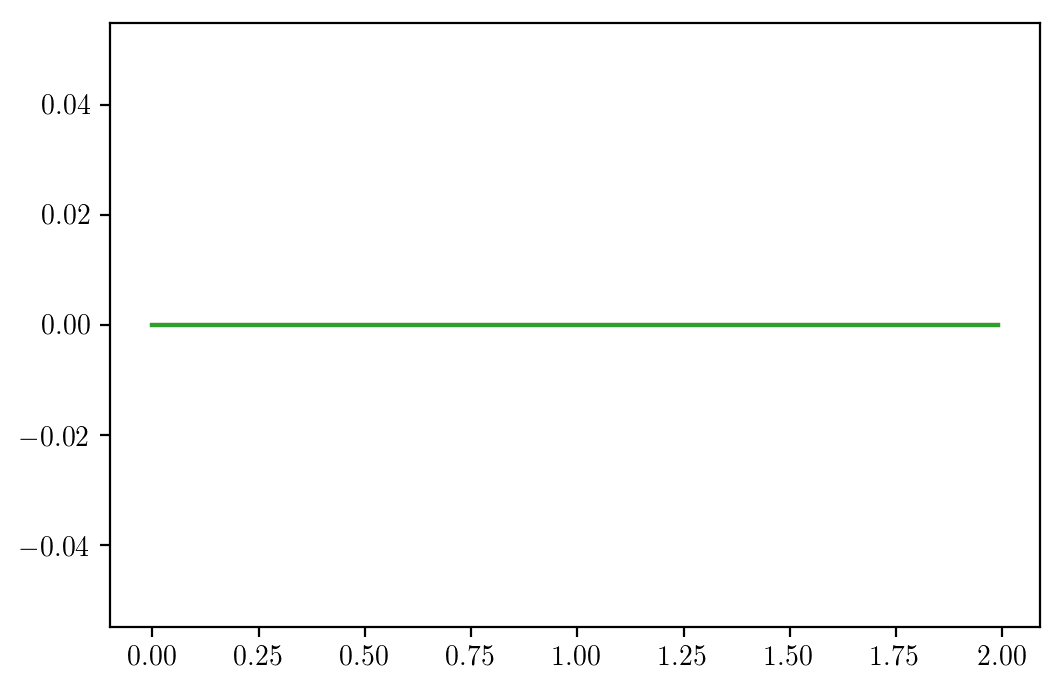

In [156]:
plt.plot(Ntab,IntegDeco11(Ntab,solPreGamma.y[0],solPreGamma.y[1],lE_ref, p_ref, xstar_ref))
plt.plot(Ntab,IntegDeco12(Ntab,solPreGamma.y[0],solPreGamma.y[1],lE_ref, p_ref, xstar_ref))
plt.plot(Ntab,IntegDeco22(Ntab,solPreGamma.y[0],solPreGamma.y[1],lE_ref, p_ref, xstar_ref))
plt.show()

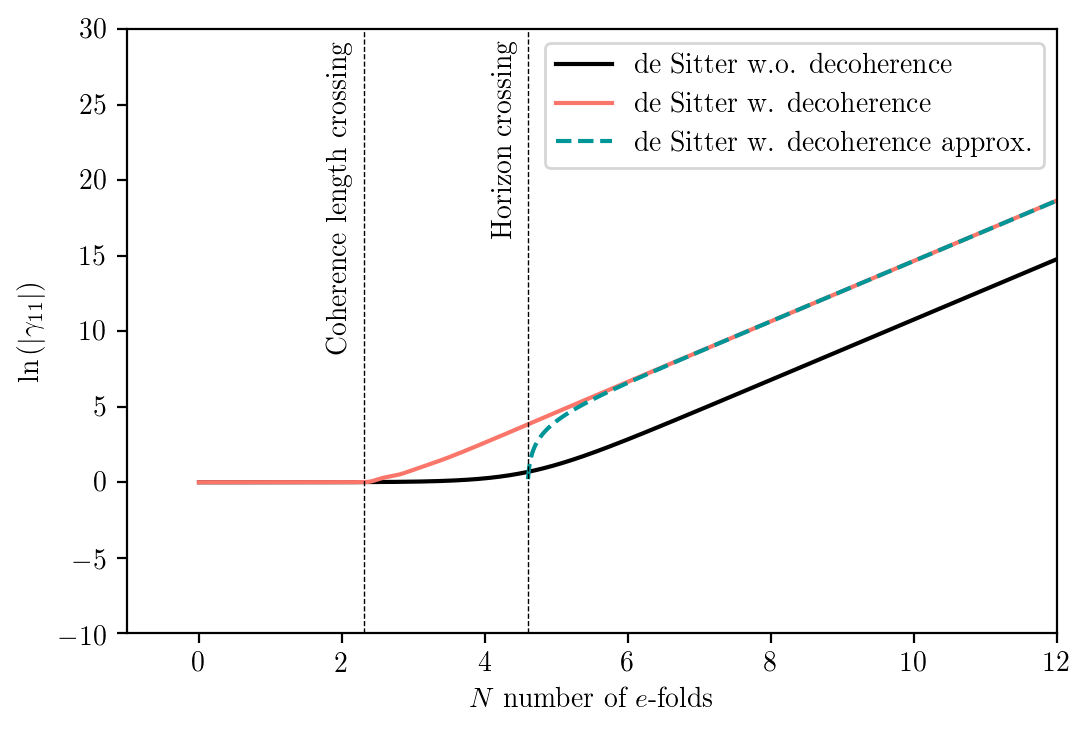

In [37]:
#plt.plot(Ntab,np.log(np.abs(solPreGamma.y[2])),color=PacificCoast,label=r'Slow-roll w.o. decoherence')
plt.plot(Ntab,np.log(Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])),'k',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,np.log(np.abs(Gam11dSDecoArray)),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab[icross_Hubble:-1],np.log(np.abs(Gam11dSDeco1stOrderArray[icross_Hubble:-1])),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
#plt.plot(Ntab,np.log(np.abs(Gamma11dSDeco1stOrder(Ntab,solPreGamma.y[0][0]*1500,solPreGamma.y[1][0]*1500,kgam_ref,lE_ref,p_ref,xstar_ref))),color=ViridianGreen,label=r'de Sitter w. decoherence L.O')
#plt.plot(Ntab[500:-1],np.log(np.abs(Gamma11dSDecoApprox(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)))[500:-1],color='k',label=r'de Sitter w. decoherence approx')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\ln \left( \left| \gamma_{11} \right| \right)$')

y_max = 30
y_min = -10
plt.plot([Ncross_ref,Ncross_ref],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
#plt.annotate(s=r'$N_{l_{E}}$', xy=(0,0), xytext=(1, -5), color="k")
#plt.annotate(s=r'$N_{H}$', xy=(0,0), xytext=(5, -5), color="k")
plt.annotate(s=r'Coherence length crossing', rotation=90, xy=(0,0), xytext=(1.8, 28), color="k")
plt.annotate(s=r'Horizon  crossing', rotation=90, xy=(0,0), xytext=(4.1, 28), color="k")
plt.ylim(y_min,y_max)

x_max = 12
plt.xlim(-1,x_max)

plt.legend()
#plt.savefig('Plots/Gamma11FirstEvoNoDeco'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
#plt.savefig('Plots/Gamma11FirstEvoNoDecoWithNs'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.savefig('Plots/Gamma11FirstEvoNoDecoWithNsDashedApprox'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Reminder : the numerical computation of the integral $A_{\alpha}$ does not work well for large number of efolds so that the ratio does not go as it should to a constant.
Mmmmm in fact it does not have to go to a constant if we take in account exactly the $\cos(x)$ in the expression of the decoherence term. This term will get closer and closer to $1$ when $x \rightarrow 0$. The fact that even when approximating $A_{\alpha}$ we still see the increase behavior might be a proof that. The cause of this increase lies rather in the expression of IntegDeco..

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:19: RuntimeWarning: overflow encountered in power
/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in multiply
  
/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in true_divide
  


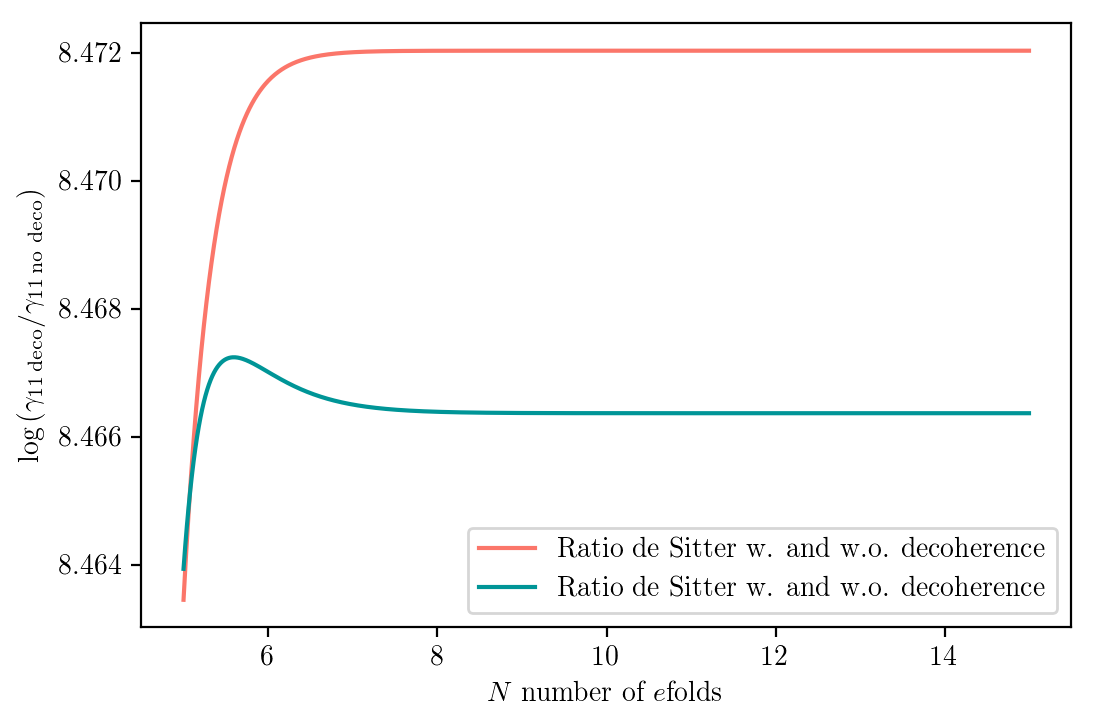

In [63]:
plt.plot(Ntab[500:1500],np.log(np.abs(Gam11dSDecoArray/Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])))[500:1500] ,color=LivingCoral,label=r'Ratio de Sitter w. and w.o. decoherence')
plt.plot(Ntab[500:1500],np.log(np.abs(Gamma11dSDecoApprox(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)/Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])))[500:1500] ,color=ViridianGreen,label=r'Ratio de Sitter w. and w.o. decoherence')
plt.xlabel(r'$N$ number of $e$folds')
plt.ylabel(r'$\log \left( \gamma_{11 \, \textrm{deco}}  / \gamma_{11 \, \text{no deco}}   \right)$')
plt.legend()
plt.show()

Plot Gamma12

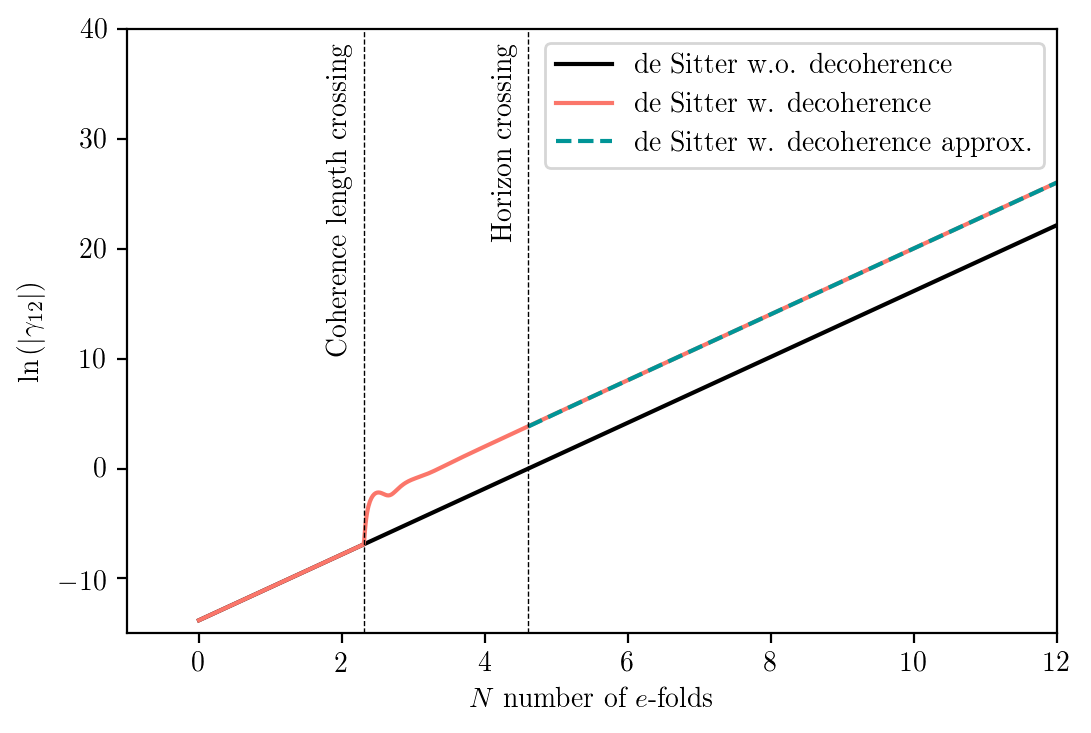

In [38]:
#plt.plot(Ntab,np.log(np.abs(solPreGamma.y[3])),color=PacificCoast,label=r'Slow-roll w.o. decoherence')
plt.plot(Ntab,np.log(Gamma12dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])),'k',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,np.log(np.abs(Gam12dSDecoArray)),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab[icross_Hubble:-1],np.log(np.abs(Gam12dSDeco1stOrderArray[icross_Hubble:-1])),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
#plt.plot(Ntab,np.log(np.abs(Gamma12dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref))),color=ViridianGreen,label=r'de Sitter w. decoherence L.O.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\ln \left( \left| \gamma_{12} \right| \right)$')

y_max = 40
y_min = -15
plt.plot([Ncross_ref,Ncross_ref],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
#plt.annotate(s=r'$N_{l_{E}}$', xy=(0,0), xytext=(1, -5), color="k")
#plt.annotate(s=r'$N_{H}$', xy=(0,0), xytext=(5, -5), color="k")
plt.annotate(s=r'Coherence length crossing', rotation=90, xy=(0,0), xytext=(1.8, 37), color="k")
plt.annotate(s=r'Horizon  crossing', rotation=90, xy=(0,0), xytext=(4.1, 37), color="k")
plt.ylim(y_min,y_max)

x_max = 12
plt.xlim(-1,x_max)

plt.legend()
#plt.savefig('Plots/Gamma12FirstEvoNoDeco'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.savefig('Plots/Gamma12FirstEvoNoDecoWithN'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Plot Gamma22

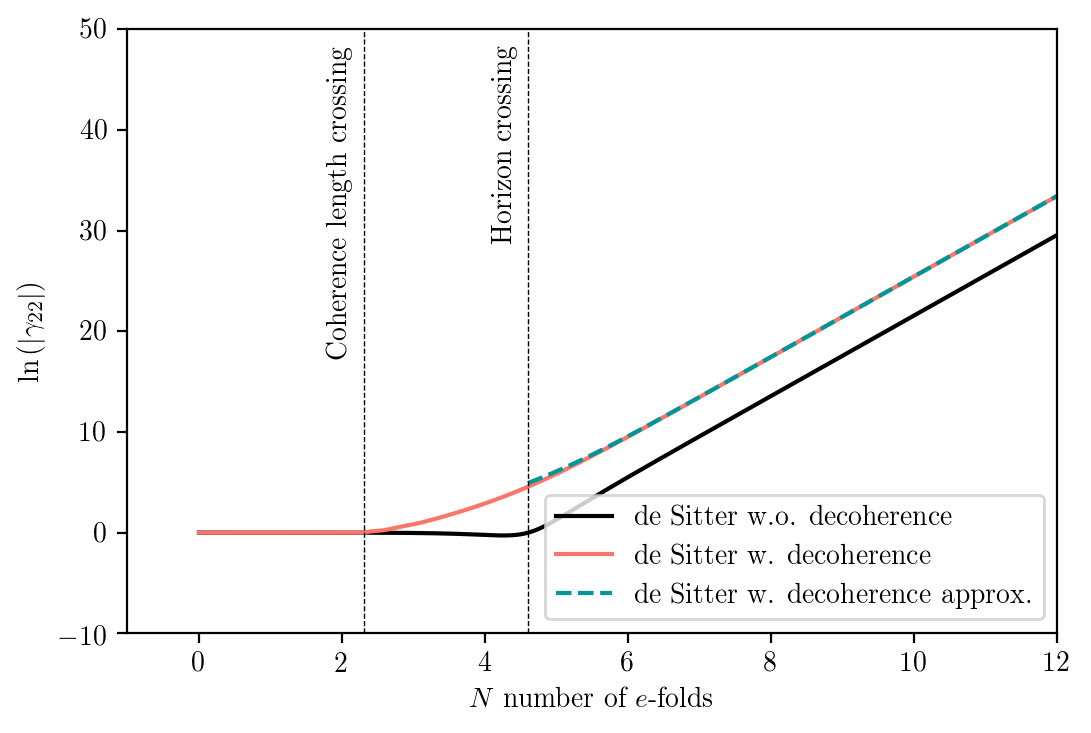

In [39]:
#plt.plot(Ntab,np.log(np.abs(solPreGamma.y[4])),color=PacificCoast,label=r'Slow-roll w.o. decoherence')
plt.plot(Ntab,np.log(Gamma22dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])),'k',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,np.log(np.abs(Gam22dSDecoArray)),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab[icross_Hubble:-1],np.log(np.abs(Gam22dSDeco1stOrderArray[icross_Hubble:-1])),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
#plt.plot(Ntab,np.log(np.abs(Gamma22dSDeco1stOrder(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref))),color=ViridianGreen,label=r'de Sitter w. decoherence L.O.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\ln \left( \left| \gamma_{22} \right| \right)$')

y_max = 50
y_min = -10
plt.plot([Ncross_ref,Ncross_ref],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
#plt.annotate(s=r'$N_{l_{E}}$', xy=(0,0), xytext=(1, -5), color="k")
#plt.annotate(s=r'$N_{H}$', xy=(0,0), xytext=(5, -5), color="k")
plt.annotate(s=r'Coherence length crossing', rotation=90, xy=(0,0), xytext=(1.8, 46.5), color="k")
plt.annotate(s=r'Horizon  crossing', rotation=90, xy=(0,0), xytext=(4.1, 46.5), color="k")
plt.ylim(y_min,y_max)

x_max = 12
plt.xlim(-1,x_max)

plt.legend(loc='lower right')
#plt.savefig('Plots/Gamma22FirstEvoNoDeco'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.savefig('Plots/Gamma22FirstEvoNoDecoWithNs'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Mathematica data for comparaison

In [313]:
Sigma2DecoMathematicaArrayfile = fits.open('Data/Sigma2ElegantArrayp6,01.fits')
Sigma2DecoMathematicaArray = np.array(Sigma2DecoMathematicaArrayfile[0].data)
Ntab2 = np.arange(0,15, deltaN)

Plot $\sigma^2(0)$ with and without decoherence. We add on top the integrals that we would get using the slow background values of the field in the expression ofr de Sitter with decoherence of the covariance matrix elements. The naive product of $\gamma$s does not give a correct result.

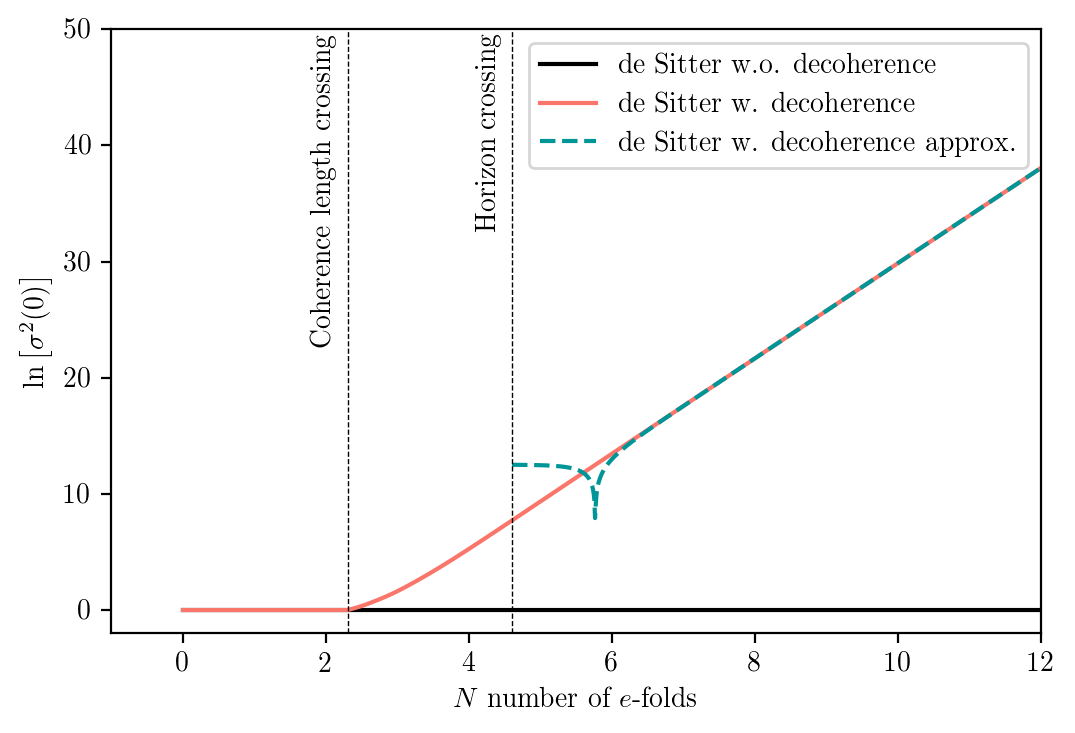

In [40]:
#plt.plot(Ntab,np.log(np.abs(Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])*Gamma22dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])-Gamma12dS(Ntab,solPreGamma.y[0],solPreGamma.y[1])**2)) ,color=PacificCoast,label=r'$\sigma^2(0)$')

plt.plot(Ntab,Ntab*0,'k',label=r'de Sitter w.o. decoherence')
#plt.plot(Ntab[0:ilim],np.log(np.abs(Gam22dSDecoArray[0:ilim]*Gam11dSDecoArray[0:ilim]-Gam12dSDecoArray[0:ilim]**2 )),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab,np.log(np.abs(Sigma2dSDecoArray)),color=LivingCoral,label=r'de Sitter w. decoherence')
#plt.plot(Ntab[500:ilim],np.log(np.abs(Sigma2dSDecoApprox(Ntab[500:ilim],solPreGamma.y[0][500:ilim],solPreGamma.y[1][500:ilim],kgam_ref,lE_ref,p_ref,xstar_ref))),color=PacificCoast,label=r'de Sitter w. decoherence exact.')
#plt.plot(Ntab[0:ilim],np.log(np.abs(Sigma2dSDeco1stOrderOnlyLin(Ntab[0:ilim],solPreGamma.y[0][0:ilim],solPreGamma.y[1][0:ilim],kgam_ref,lE_ref,p_ref,xstar_ref))),color=Pantone808Green,label=r'de Sitter w. decoherence L.0.')
plt.plot(Ntab[icross_Hubble:-1],np.log(np.abs(Sig2dSDeco1stOrderArray[icross_Hubble:-1])),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
#plt.plot(Ntab2,np.log(np.abs(Sigma2DecoMathematicaArray)),color=PapayaPunch,label=r'Mathematica')


plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\ln \left[ \sigma^{2}(0) \right]$')

y_max = 50
y_min = -2
plt.plot([Ncross_ref,Ncross_ref],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
#plt.annotate(s=r'$N_{l_{E}}$', xy=(0,0), xytext=(1, 10), color="k")
#plt.annotate(s=r'$N_{H}$', xy=(0,0), xytext=(5, 10), color="k")
plt.annotate(s=r'Coherence length crossing', rotation=90, xy=(0,0), xytext=(1.8, 48), color="k")
plt.annotate(s=r'Horizon  crossing', rotation=90, xy=(0,0), xytext=(4.1, 48), color="k")
plt.ylim(y_min,y_max)

x_max = 12
plt.xlim(-1,x_max)

plt.legend()
plt.savefig('Plots/Sigma2FirstEvoNoDecoWithNs'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

To save the resulting $\sigma^2$ in a format usable with Mathematica

In [ ]:
Sigma2MathematicaArray = Gamma11dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)*Gamma22dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE,p_ref,xstar_ref)-Gamma12dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE,p_ref,xstar_ref)**2
Sigma2MathematicaArray.astype('float64').tofile('Sigma2.dat')

# Squeezing parameters

In [33]:
def rkSqueezing(Gamma11,Gamma12,Gamma22,Sigma2):
    return(np.arccosh((Gamma11+Gamma22)/np.sqrt(Sigma2)/2)/2)

def PhikSqueezing(Gamma11,Gamma12,Gamma22,Sigma2):
    return(2*np.arctan(-Gamma12/(Gamma22-Gamma11))/2)

Explicit expression for de Sitter

In [34]:
def rkSqueezingdS(N):
    return(np.arccosh(1+ (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**4/2  )/2)

def PhikSqueezingdS(N):
    x_temp =  k_0*np.exp(-(N-N_0))/a_0/H(N_0 , phi_0 , phidot_0)
    return(np.arctan( -2*x_temp/(1-2*x_temp**2)  )/2 -np.pi*np.heaviside(x_temp - 1/np.sqrt(2), 1)/2  )

Array for the value of the squeezing parameters computed using the expression using Python incomplete $\Gamma$

In [47]:
rkSqueezingArray = rkSqueezing(Gam11dSDecoArray,Gam12dSDecoArray,Gam22dSDecoArray,Sigma2dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref))
PhikSqueezingArray = PhikSqueezing(Gam11dSDecoArray,Gam12dSDecoArray,Gam22dSDecoArray,Sigma2dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref))
LambdakSqueezingArray = Sigma2dSDecoArray

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  
/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in arccosh
  


Arrays obtained using the 1st order approximation

In [192]:
LambdakSqueezingArray1stOrder = Sig2dSDeco1stOrderArray

In [88]:
rkSqueezingArray1stOrder = rkSqueezing(Gam11dSDeco1stOrderArray,Gam12dSDeco1stOrderArray,Gam22dSDeco1stOrderArray,LambdakSqueezingArray1stOrder)
PhikSqueezingArray1stOrder = PhikSqueezing(Gam11dSDeco1stOrderArray,Gam12dSDeco1stOrderArray,Gam22dSDeco1stOrderArray,LambdakSqueezingArray1stOrder)

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in arccosh
  


In [394]:
Ntab.astype('float64').tofile('Ntab.dat')
rkSqueezingArray1stOrder.astype('complex128').tofile('Data/rk.dat')
PhikSqueezingArray1stOrder.astype('complex128').tofile('Data/Phik.dat')
LambdakSqueezingArray1stOrder.astype('complex128').tofile('Data/Lambdak.dat')

Plot $r_{k}$

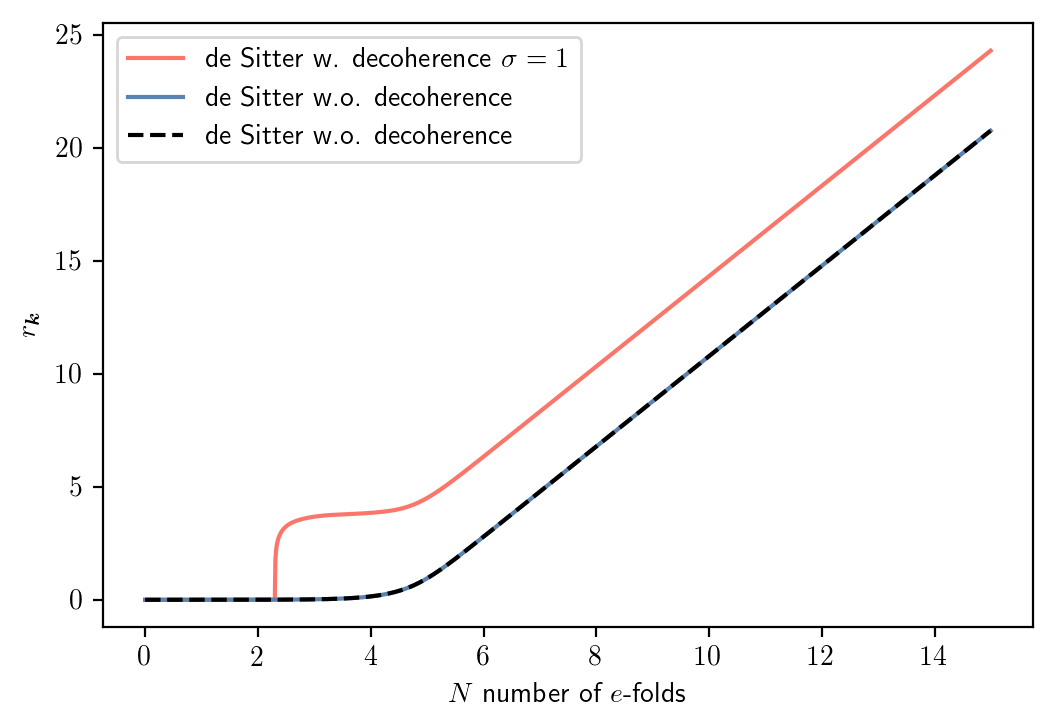

In [191]:
plt.plot(Ntab,rkSqueezing(Gam11dSDecoArray,Gam12dSDecoArray,Gam22dSDecoArray,1),color=LivingCoral,label=r'de Sitter w. decoherence $\sigma = 1$')
plt.plot(Ntab,rkSqueezingdS(Ntab),color=PacificCoast,label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,rkSqueezing(Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma12dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma22dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),1),'k--',label=r'de Sitter w.o. decoherence')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$r_{\bm{k}}$')
plt.legend()
#plt.savefig('rkSigma2=1'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

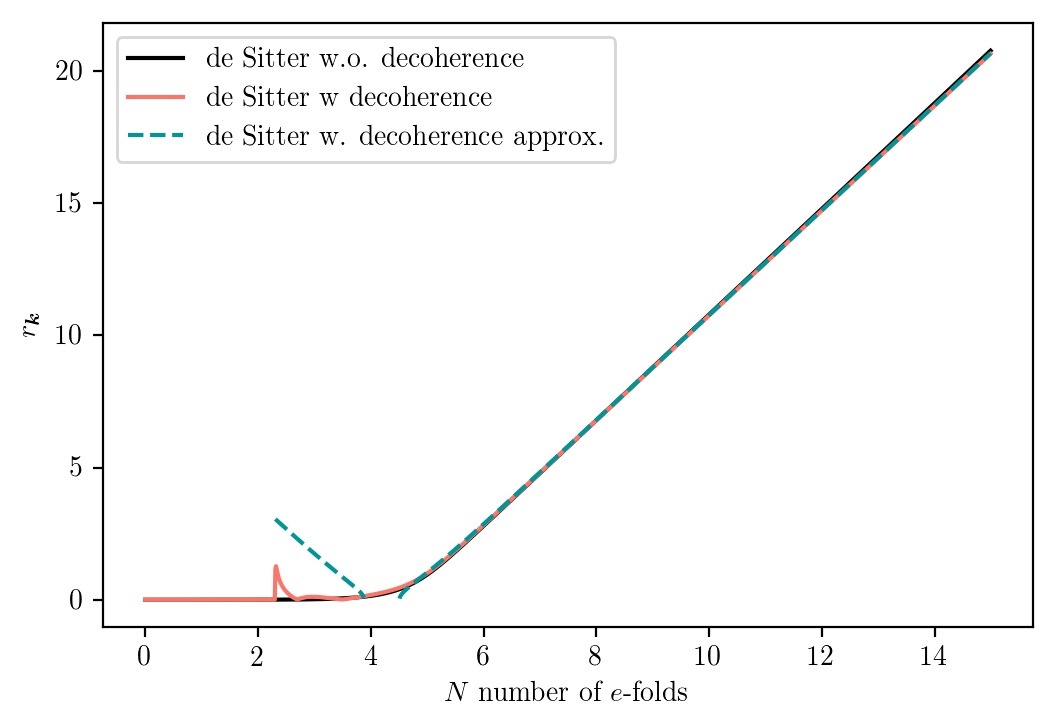

In [118]:
plt.plot(Ntab,rkSqueezingdS(Ntab),'k',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,rkSqueezing(Gam11dSDecoArray,Gam12dSDecoArray,Gam22dSDecoArray,Sigma2dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)),color=LivingCoral,label=r'de Sitter w decoherence')
plt.plot(Ntab,np.real(rkSqueezingArray1stOrder),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$r_{\bm{k}}$')
plt.legend()
#plt.savefig('rk'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Plot for $\varphi_{\bf{k}}$

/home/amaury/.local/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


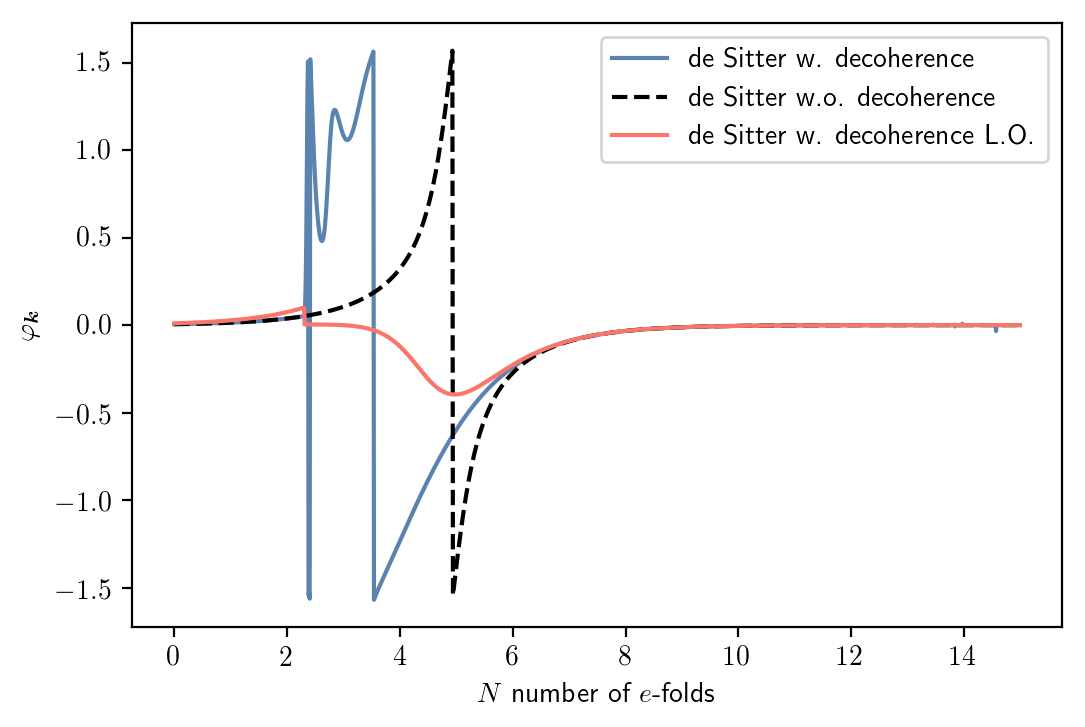

In [388]:
plt.plot(Ntab,PhikSqueezing(Gam11dSDecoArray,Gam12dSDecoArray,Gam22dSDecoArray,Sigma2dSDeco(Ntab,solPreGamma.y[0],solPreGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab,PhikSqueezing(Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma12dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma22dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),1),'k--',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,np.real(PhikSqueezingArray1stOrder),color=ViridianGreen,label=r'de Sitter w. decoherence L.O.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\varphi_{\bm{k}}$')
plt.legend()
plt.savefig('phik'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Plot of $\lambda_{\bf{k}}$

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log
  """Entry point for launching an IPython kernel.


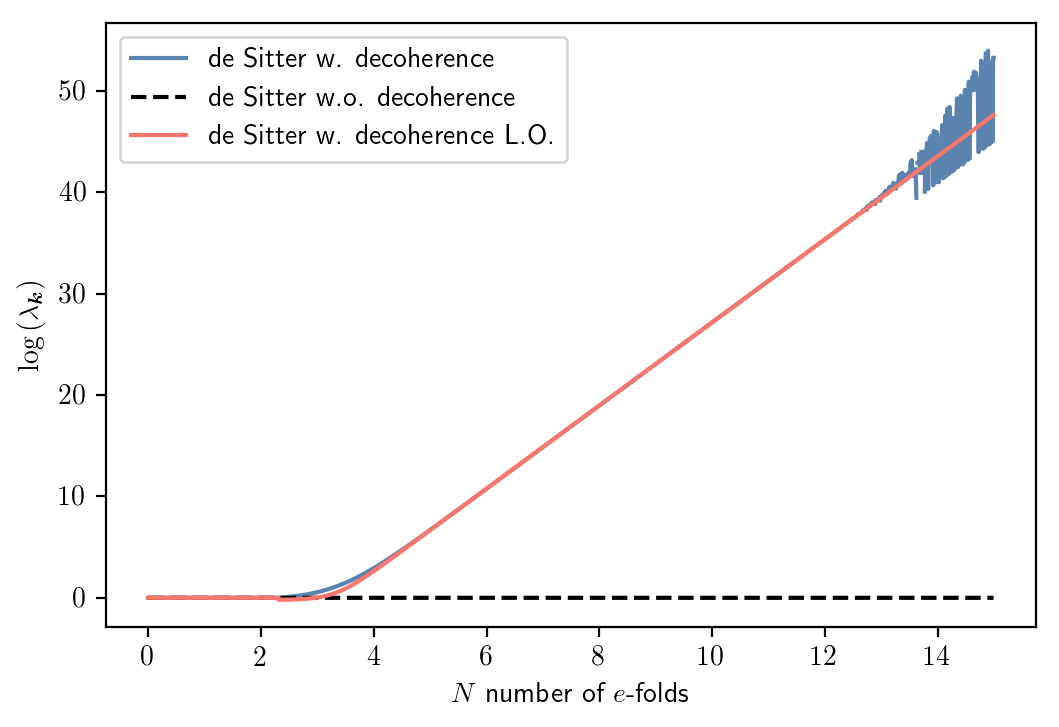

In [389]:
plt.plot(Ntab2,np.log(LambdakSqueezingArray),color=LivingCoral,label=r'de Sitter w. decoherence')
plt.plot(Ntab,0*Ntab,'k--',label=r'de Sitter w.o. decoherence')
plt.plot(Ntab,np.log(LambdakSqueezingArray1stOrder),color=ViridianGreen,label=r'de Sitter w. decoherence L.O.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\log \left( \lambda_{\bm{k}} \right)$')
plt.legend()
plt.savefig('lambdak'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

# Discord

Symplectic eigenvalue Sigma(Theta) of the diagonal submatrices in the partition labeled by Theta

In [44]:
def Sigma(Gamma11,Gamma21,Gamma22,theta):
    return(np.sqrt(Gamma11*Gamma22-Gamma21**2 + ( (Gamma11**2 - Gamma22**2) + 4 *  Gamma21**2 )/4 * (np.sin(2*theta)**2 ) )            )
    
def SigmaSig(Gamma11,Sig2,Gamma22,theta):
    return(np.sqrt(Sig2*np.cos(2*theta)**2 + ((Gamma11 + Gamma22)*np.sin(2*theta) /2)**2 ) )
    
def SigmaNoDeco(Gamma11,Gamma21,Gamma22,theta):
    return(np.sqrt(np.cos(2*theta)**2 + ((Gamma11 + Gamma22)*np.sin(2*theta) /2)**2 ) )

Several version of a function used to compute the discord

In [45]:
def ffunc(x):
    return ( -xlogy((x-1)/2,(x-1)/(x+1)) + np.log((x+1)/2)  )
 
# The following function is not suitable for large number as the difference of the two terms is approximated to 0.
#xlogy handles well the limit x goes to 0 contrary to x*np.log
def ffunc1(x):
    return ( (xlogy((x+1)/2,(x+1)/2) - xlogy((x-1)/2,(x-1)/2))/np.log(2) ) 

# The following function is not suitable for small numbers. It is an approximated expression of the real ffunc for large x
def ffunc2(x):
    return ( (np.log(x/2) +1)/np.log(2)  )    

# Functions written using another logarithm function supposed to handle large numbers. It cannot be applied on arrays !
def ffuncalt(x):
    try :
        Res = -((x-1)/2)*mlog((x-1)/(x+1)) + mlog((x+1)/2) 
    except ValueError :
        Res = 0
    return ( Res )
    
#Function that applies on an array    
def effectiveffunc(x):
    xtemp = np.where(x <= 1 , 1, x )
    xtemp = np.where(xtemp >= 1000 , ffunc2(xtemp) , ffunc1(xtemp) )
    return(xtemp)


Actual computation of the discord

In [46]:
def Discord(Gamma11,Gamma21,Gamma22,theta):
    SigTemp = Sigma(Gamma11,Gamma21,Gamma22,theta).real
    SigTemp0 = Sigma(Gamma11,Gamma21,Gamma22,0).real
    return( effectiveffunc(SigTemp) - 2*effectiveffunc(SigTemp0) + effectiveffunc( (SigTemp**2 + SigTemp0**2)/(SigTemp +1) ) )
    
def DiscordSigma(Gamma11,Sig2,Gamma22,theta):
    SigTemp0 = np.sqrt(Sig2).real
    #SigTemp0 = SigmaSig(Gamma11,Sig2,Gamma22,0).real
    SigTemp = SigmaSig(Gamma11,Sig2,Gamma22,theta).real
    temp = effectiveffunc(SigTemp) - 2*effectiveffunc(SigTemp0) + effectiveffunc( (SigTemp + SigTemp0**2)/(SigTemp +1) )
    return( effectiveffunc(SigTemp) - 2*effectiveffunc(SigTemp0) + effectiveffunc( (SigTemp + SigTemp0**2)/(SigTemp +1) ) )

    
def DiscordNoDeco(Gamma11,Gamma21,Gamma22,theta):
    SigTemp = SigmaNoDeco(Gamma11,Gamma21,Gamma22,theta).real
    SigTemp0 = SigmaNoDeco(Gamma11,Gamma21,Gamma22,0).real
    return( effectiveffunc(SigTemp) - 2*effectiveffunc(SigTemp0) + effectiveffunc( (SigTemp**2 + SigTemp0**2)/(SigTemp +1) ) )

 Plot of $\mathcal{D}_{k}$

In [47]:
Ntab[icross_Hubble]
Ncross_Hubble

4.605170185988092

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in sqrt
  import sys


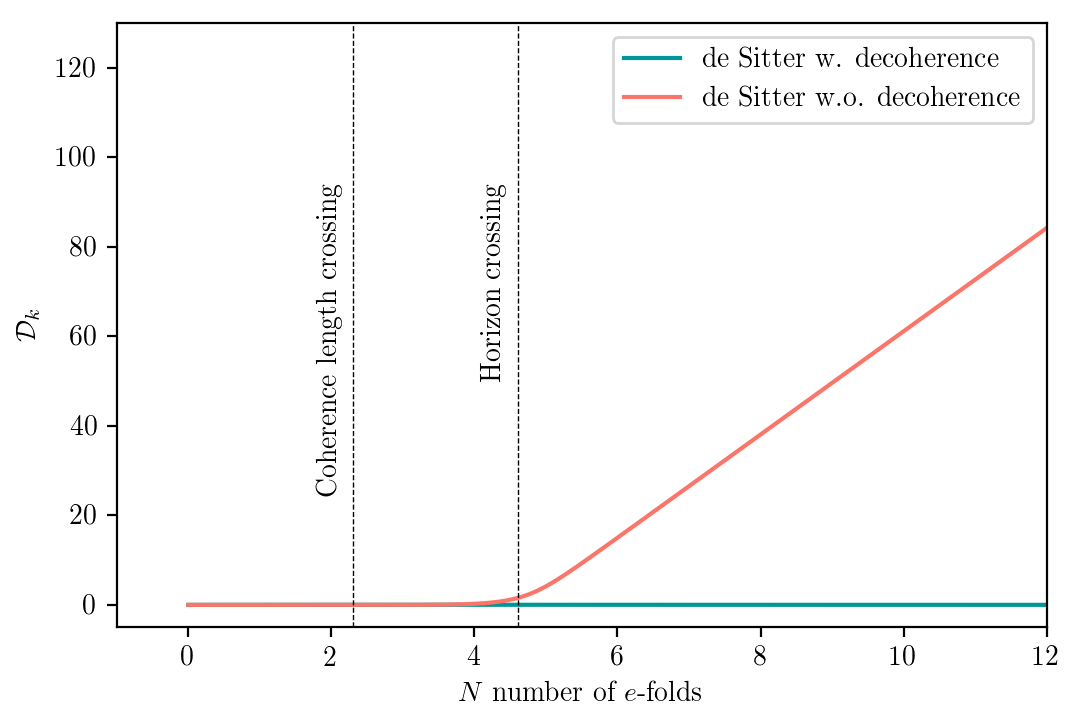

In [48]:
plt.plot(Ntab,DiscordSigma(Gam11dSDecoArray,Sigma2dSDecoArray,Gam22dSDecoArray,np.pi/4),color=ViridianGreen,label=r'de Sitter w. decoherence')
plt.plot(Ntab,DiscordNoDeco(Gamma11dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma12dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),Gamma22dS(Ntab,solPreGamma.y[0],solPreGamma.y[1]),np.pi/4),color=LivingCoral,label=r'de Sitter w.o. decoherence')
#plt.plot(Ntab[icross_Hubble:-1],DiscordSigma(Gam11dSDeco1stOrderArray[icross_Hubble:-1],np.abs(Sig2dSDeco1stOrderArray[icross_Hubble:-1]),Gam22dSDeco1stOrderArray[icross_Hubble:-1],np.pi/4),color=ViridianGreen,linestyle='--',label=r'de Sitter w. decoherence approx.')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\mathcal{D}_{k}$')



y_max = 130
y_min = -5
plt.ylim(y_min,y_max)

plt.plot([Ncross_ref,Ncross_ref],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
#plt.annotate(s=r'$N_{l_{E}}$', xy=(0,0), xytext=(1, 10), color="k")
#plt.annotate(s=r'$N_{H}$', xy=(0,0), xytext=(5, 10), color="k")
plt.annotate(s=r'Coherence length crossing', rotation=90, xy=(0,0), xytext=(1.8, 90), color="k")
plt.annotate(s=r'Horizon crossing', rotation=90, xy=(0,0), xytext=(4.1, 90), color="k")


#plt.yscale('log')

x_max = 12
plt.xlim(-1,x_max)

plt.legend(loc=0)
#plt.savefig('Plots/DiscordkMinusk'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.savefig('Plots/DiscordkMinuskNoApprox'+np.str(kgam_ref/k_0)+'p'+np.str(p_ref)+'.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

In [48]:
Ntab2 = np.arange(N_0, 60, 0.05)

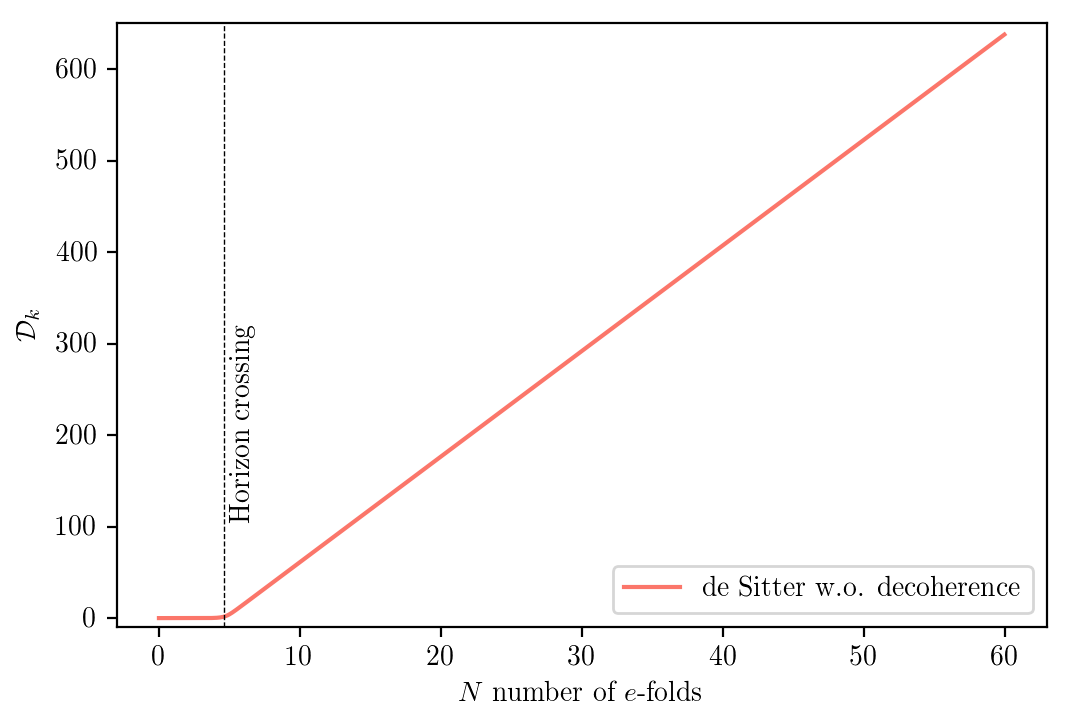

In [58]:
plt.plot(Ntab2,DiscordNoDeco(Gamma11dS(Ntab2,Ntab2,Ntab2),Gamma12dS(Ntab2,Ntab2,Ntab2),Gamma22dS(Ntab2,solPreGamma.y[0],solPreGamma.y[1]),np.pi/4),color=LivingCoral,label=r'de Sitter w.o. decoherence')
plt.xlabel(r'$N$ number of $e$-folds')
plt.ylabel(r'$\mathcal{D}_{k}$')


y_max = 650
y_min = -10
plt.ylim(y_min,y_max)

plt.plot([Ncross_Hubble,Ncross_Hubble],[y_min,y_max],'k',linestyle='--',linewidth=0.5)
plt.annotate(s=r'Horizon crossing', rotation=90, xy=(0,0), xytext=(5.1, 300), color="k")


#plt.yscale('log')



plt.legend()
plt.savefig('Plots/DiscordkMinusdeSitter.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

# Plots ellipses

## Single ellipse

Plot reference inner circle

In [36]:
def PlotInnerCircle(linewidth_temp):
    t = np.linspace(0, 2*np.pi, 100) #Number of points used to plot the ellipse
    xcircle = np.cos(t)
    ycircle = np.sin(t)
    plt.fill(xcircle,ycircle,color=LivingCoral,alpha=.3)
    plt.plot(xcircle,ycircle,linewidth=linewidth_temp,color='k',linestyle='dashed')

In [37]:
def PlotInnerCircleWhite(linewidth_temp):
    t = np.linspace(0, 2*np.pi, 100) #Number of points used to plot the ellipse
    xcircle = np.cos(t)
    ycircle = np.sin(t)
    plt.fill(xcircle,ycircle,color='w')

Plot streched ellipse

In [38]:
def PlotEllipse(u,v,r_temp,t_rot_temp,lamb_temp,linewidth_temp):
    SemiMinor1 = np.sqrt(np.sqrt(lamb_temp))*np.exp(-r_temp)       #Initially aligned along the x-axis
    SemiMajor1 = np.sqrt(np.sqrt(lamb_temp))*np.exp(r_temp)       #Initially aligned along the y-axis
    t = np.linspace(0, 2*np.pi, 100) #Number of points used to plot the ellipse
    Ell1_ini = np.array([SemiMinor1*np.cos(t) , SemiMajor1*np.sin(t)]) #Plot of the ellipse using a parametric equation  
     #u,v removed to keep the same center location
    R_rot = np.array([[np.cos(t_rot_temp) , -np.sin(t_rot_temp)],[np.sin(t_rot_temp) , np.cos(t_rot_temp)]])   #2-D rotation matrix
    Ell1 = np.zeros((2,Ell1_ini.shape[1])) #Ell.shape[1] is equal to the number of points sued to plots the ellipse
    for i in range(Ell1_ini.shape[1]): #For each point we pick its coordinates, which correspond to pick a column Ell[:,i] in the 2 by Ell.shape[1] size matrix, and rotate it.
        Ell1[:,i] = np.dot(R_rot,Ell1_ini[:,i])
    plt.fill(u+Ell1[0,:] , v+Ell1[1,:],color=ViridianGreen,alpha=.5)
    plt.plot( u+Ell1[0,:] , v+Ell1[1,:],linewidth=linewidth_temp,color='k')    #rotated ellipse   

Plot annotation

In [39]:
def PlotAnnotationEllipse(u,v,r_temp,t_rot_temp,lamb,linewidth_temp,tailwidth_temp,fontsize_temp):
    SemiMinor1 = np.sqrt(np.sqrt(lamb))*np.exp(-r_temp)       #Initially aligned along the x-axis
    SemiMajor1 = np.sqrt(np.sqrt(lamb))*np.exp(r_temp)       #Initially aligned along the y-axis
    t = np.linspace(0, 2*np.pi, 100) #Number of points used to plot the ellipse
    Ell1_ini = np.array([SemiMinor1*np.cos(t) , SemiMajor1*np.sin(t)]) #Plot of the ellipse using a parametric equation  
     #u,v removed to keep the same center location
    R_rot = np.array([[np.cos(t_rot_temp) , -np.sin(t_rot_temp)],[np.sin(t_rot_temp) , np.cos(t_rot_temp)]])   #2-D rotation matrix with a minus sign due to our conventions
    Ell1 = np.zeros((2,Ell1_ini.shape[1])) #Ell.shape[1] is equal to the number of points sued to plots the ellipse
    for i in range(Ell1_ini.shape[1]): #For each point we pick its coordinates, which correspond to pick a column Ell[:,i] in the 2 by Ell.shape[1] size matrix, and rotate it.
        Ell1[:,i] = np.dot(R_rot,Ell1_ini[:,i])
    
    #Reference axes (can be replaced by a grid to make the plot lighter)
    plt.arrow(0, 0, 0, 1, head_width=0.05,color="k",linewidth=linewidth_temp,linestyle='-', length_includes_head=True) #Plot an arrow along the semi-minor and semi-major axis. length_includes_head allows to be more precise when giving the legnth to include the lenght in the plot
    plt.arrow(0, 0, 1, 0, head_width=0.05,color="k",linewidth=linewidth_temp,linestyle='-', length_includes_head=True)
    # plt.grid(color='lightgray',linestyle='--')
    #plt.grid(color='k',linestyle='--')
    
    #Arrows for ellipse's principal axis
    vec_semimajor1 = np.dot(R_rot,np.array([0,SemiMajor1]).reshape(2,1)).reshape(1,2)[0] #np.transpose() does not work for line vector so we have to use reshape to go from line vector to column then back to line
# [0] allows to remove one dimension
    plt.arrow(0, 0, vec_semimajor1[0], vec_semimajor1[1],linewidth=linewidth_temp,head_width=0.05, color="k", length_includes_head=True) #Plot an arrow along the semi-minor and semi-major axis. length_includes_head allows to be more precise when giving the legnth to include the lenght in the plot
#The above plots a nice arrow but cannot make it double headed
    #plt.annotate(s='', xy=(0,0), xytext=(vec_semiminor[0], vec_semiminor[1]), color=ViridianGreen, arrowprops=dict(arrowstyle='<->'))
    vec_semiminor1 = np.dot(R_rot,np.array([SemiMinor1,0]).reshape(2,1)).reshape(1,2)[0] 
    plt.arrow(0, 0, vec_semiminor1[0], vec_semiminor1[1],linewidth=linewidth_temp, head_width=0.05, color="k", length_includes_head=True) #Plot an arrow along the semi-minor and semi-major axis. length_includes_head allows to be more precise when giving the legnth to include the lenght in the plot

    #Curved arrows to show the angle (Extra complications..)
    style = "Simple, tail_width="+np.str(tailwidth_temp)+", head_width="+np.str(20*tailwidth_temp)+", head_length="+np.str(3)
    kw = dict(arrowstyle=style, color="k")
    optimal_rad = 2* 0.1*SemiMajor1*(1-np.cos(t_rot_temp/2))/SemiMinor1 #Optimal radius to use to imitate an arc circle given that arc3 is a quadratic Beziers curve see https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.ConnectionStyle.html#matplotlib.patches.ConnectionStyle
    #and https://fr.wikipedia.org/wiki/Courbe_de_B%C3%A9zier#Exemples
    CurvedArrowPhixaxis1 = patches.FancyArrowPatch((0.1*SemiMajor1, 0),(0.7*vec_semiminor1[0], 0.7*vec_semiminor1[1]),connectionstyle="arc3,rad="+np.str(optimal_rad),**kw) #Need to find how to include length_includes_head=True
    CurvedArrowPhiyaxis1 = patches.FancyArrowPatch((0,0.1*SemiMajor1), (0.1*vec_semimajor1[0], 0.1*vec_semimajor1[1]),connectionstyle="arc3,rad="+np.str(optimal_rad),**kw) #Need to find how to include length_includes_head=True
    plt.gca().add_patch(CurvedArrowPhixaxis1)
    plt.gca().add_patch(CurvedArrowPhiyaxis1)

    #Annotation on the curved arrows
    plt.annotate(s=r'$\varphi_{\bm{k}}$', xycoords='polar', xy=(np.pi/2+3*t_rot/4,SemiMinor1), color="k", fontsize=fontsize_temp) #xycoords='polar' allows to then give the cooordinates using a polar system

    #Annotations on top of the plot
    #annotation_semiminor1 = np.dot(R_rot,np.array([-0.5*SemiMinor1,0.5*SemiMinor1]).reshape(2,1)).reshape(1,2)[0]
    annotation_semiminor1 = np.array([-SemiMinor1,-0.1])
    annotation_semiminor1 = 1.1*vec_semiminor1
    plt.annotate(s=r'$e^{-r_{\bm{k}}}$', xy=(annotation_semiminor1[0], annotation_semiminor1[1]), color="k", fontsize=fontsize_temp)
    #annotation_semimajor1 = np.dot(R_rot,np.array([0.5*SemiMajor1,0.5*SemiMajor1]).reshape(2,1)).reshape(1,2)[0]
    annotation_semimajor1 = vec_semimajor1*0.5+vec_semiminor1*0.2
    plt.annotate(s=r'$e^{r_{\bm{k}}}$',  xy=(annotation_semimajor1[0],annotation_semimajor1[1]), color="k", fontsize=fontsize_temp)
    #plt.annotate(s=r'$\lambda_{\mathbf{k}} = $'+np.str(round(lambda1circle,4)), xy=(0.3*min(Ell1[0]), 0.7*max(Ell1[1])), color=PacificCoast, fontsize=20)
#Annotation for Lambda_k
    #plt.annotate(s=r'$\lambda_{\bm{k}} = $'+np.str(round(lamb,4)), xy=(min(Ell1[0]), 0.8*max(Ell1[1])), color=ViridianGreen, fontsize=fontsize_temp)
    # semimajorpatch = TextPath((0.5*SemiMajor1,0.3*SemiMajor1), r'$e^{r}$', fontsize=15,size=0.2, usetex=True) #This way of annotating text gives a text whose position is fixed with respect to the other plots and whose size scales when zooming BUT it has weird quality problem
    # plt.gca().add_patch(PathPatch(semimajorpatch, color="k"))
    #ax.set_title(r'$\sqrt{2}-\sigma$ contour of the Wigner function in $s$ sector')




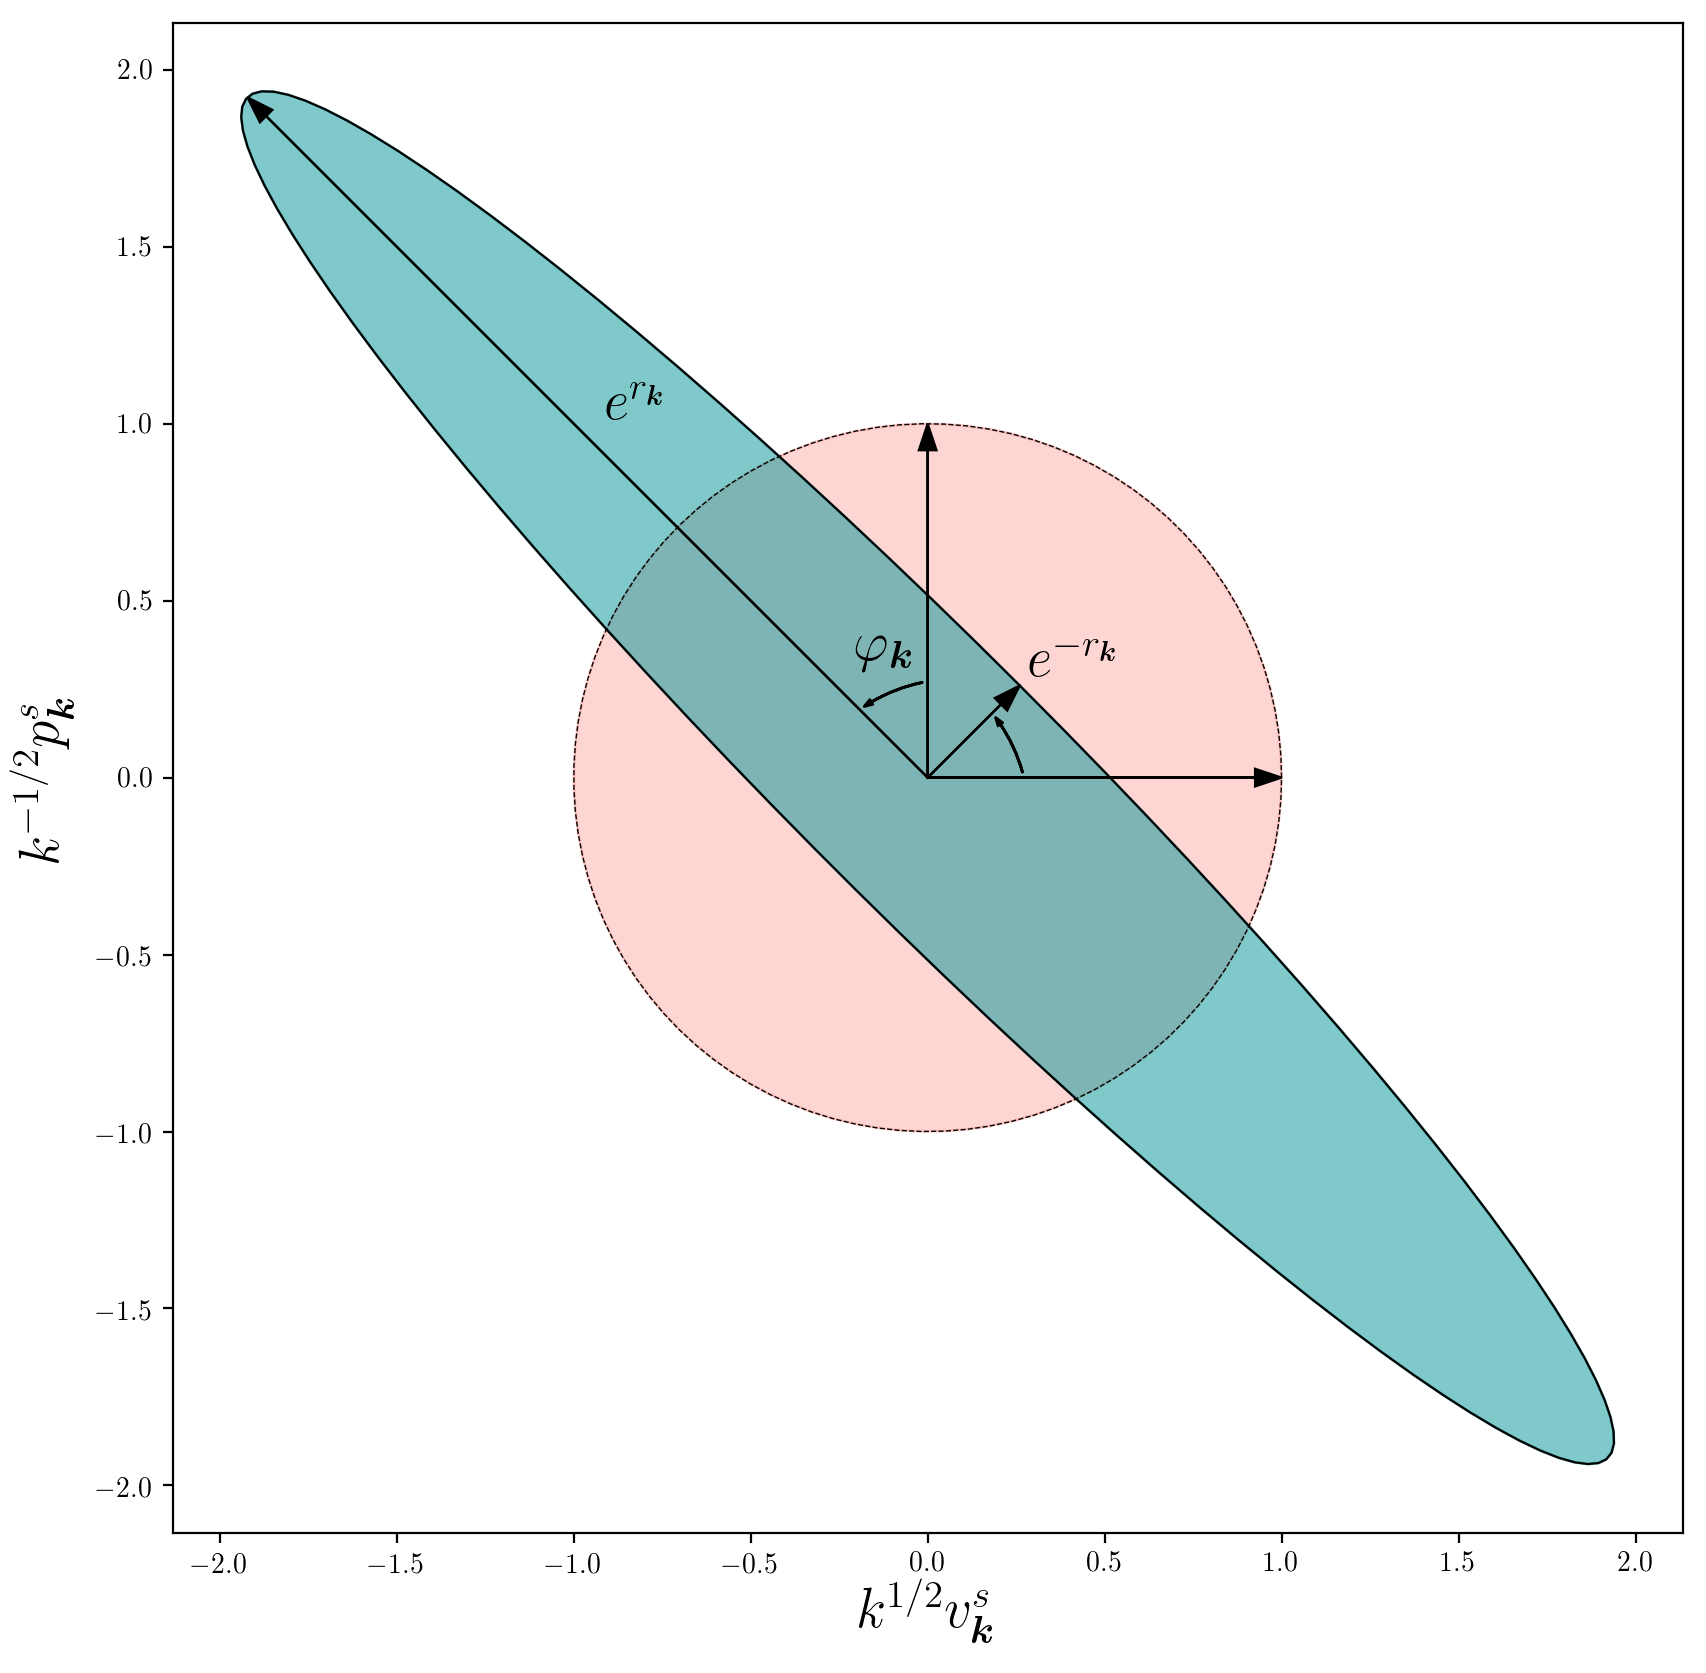

In [40]:
u = 0       #x-position of the center
v = 0     #y-position of the center
r = 1 #Squeezing parameter
t_rot = np.pi/4 #Squeezing rotation angle
lamb = 1 #Area of ellipse is np.pi*np.sqrt(lamb)

fig, axs = plt.subplots(figsize=(10,10))

axs.set_aspect(1)
PlotInnerCircle(0.5)
PlotEllipse(u,v,r,t_rot,lamb,0.8)
PlotAnnotationEllipse(u,v,r,t_rot,lamb,0.8,0.1,20)

 #Square figure to respect the aspect of the plot
axs.set_xlabel(r'$k^{1/2}v^{s}_{\bm{k}}$',fontsize=20)
axs.set_ylabel(r'$k^{-1/2}p^{s}_{\bm{k}}$',fontsize=20)

plt.savefig('Plots/SingledEllipse.pdf', format='pdf' ,  bbox_inches = 'tight')


plt.show()

## Rotating ellipses without decoherence

In [51]:
def rkSqueezingdS(N):
    return(np.arccosh(1+ (np.exp((N-N_0))*a_0*H(N_0 , phi_0 , phidot_0)/k_0)**4/2  )/2)

def PhikSqueezingdS2(N):
    x_temp = k_0*np.exp(-(N-N_0))/a_0/H(N_0 , phi_0 , phidot_0)
    return(np.arctan( -2*x_temp/(1-2*x_temp**2)  )/2 -np.pi*np.heaviside(x_temp - 1/np.sqrt(2), 1)/2  )

def PhikSqueezingdS(N):
    x_temp = k_0*np.exp(-(N-N_0))/a_0/H(N_0 , phi_0 , phidot_0)
    return(-np.pi/4 + np.arctan( -x_temp + 1/x_temp/2 )/2)

In [52]:
u= 0       #x-position of the center
v= 0     #y-position of the center

NList = np.array([0,4.5,4.8,5,5.2,10])
LambdaList = np.array([1 for i in range(6)])
rList = rkSqueezingdS(NList)
PhiList =  PhikSqueezingdS(NList)

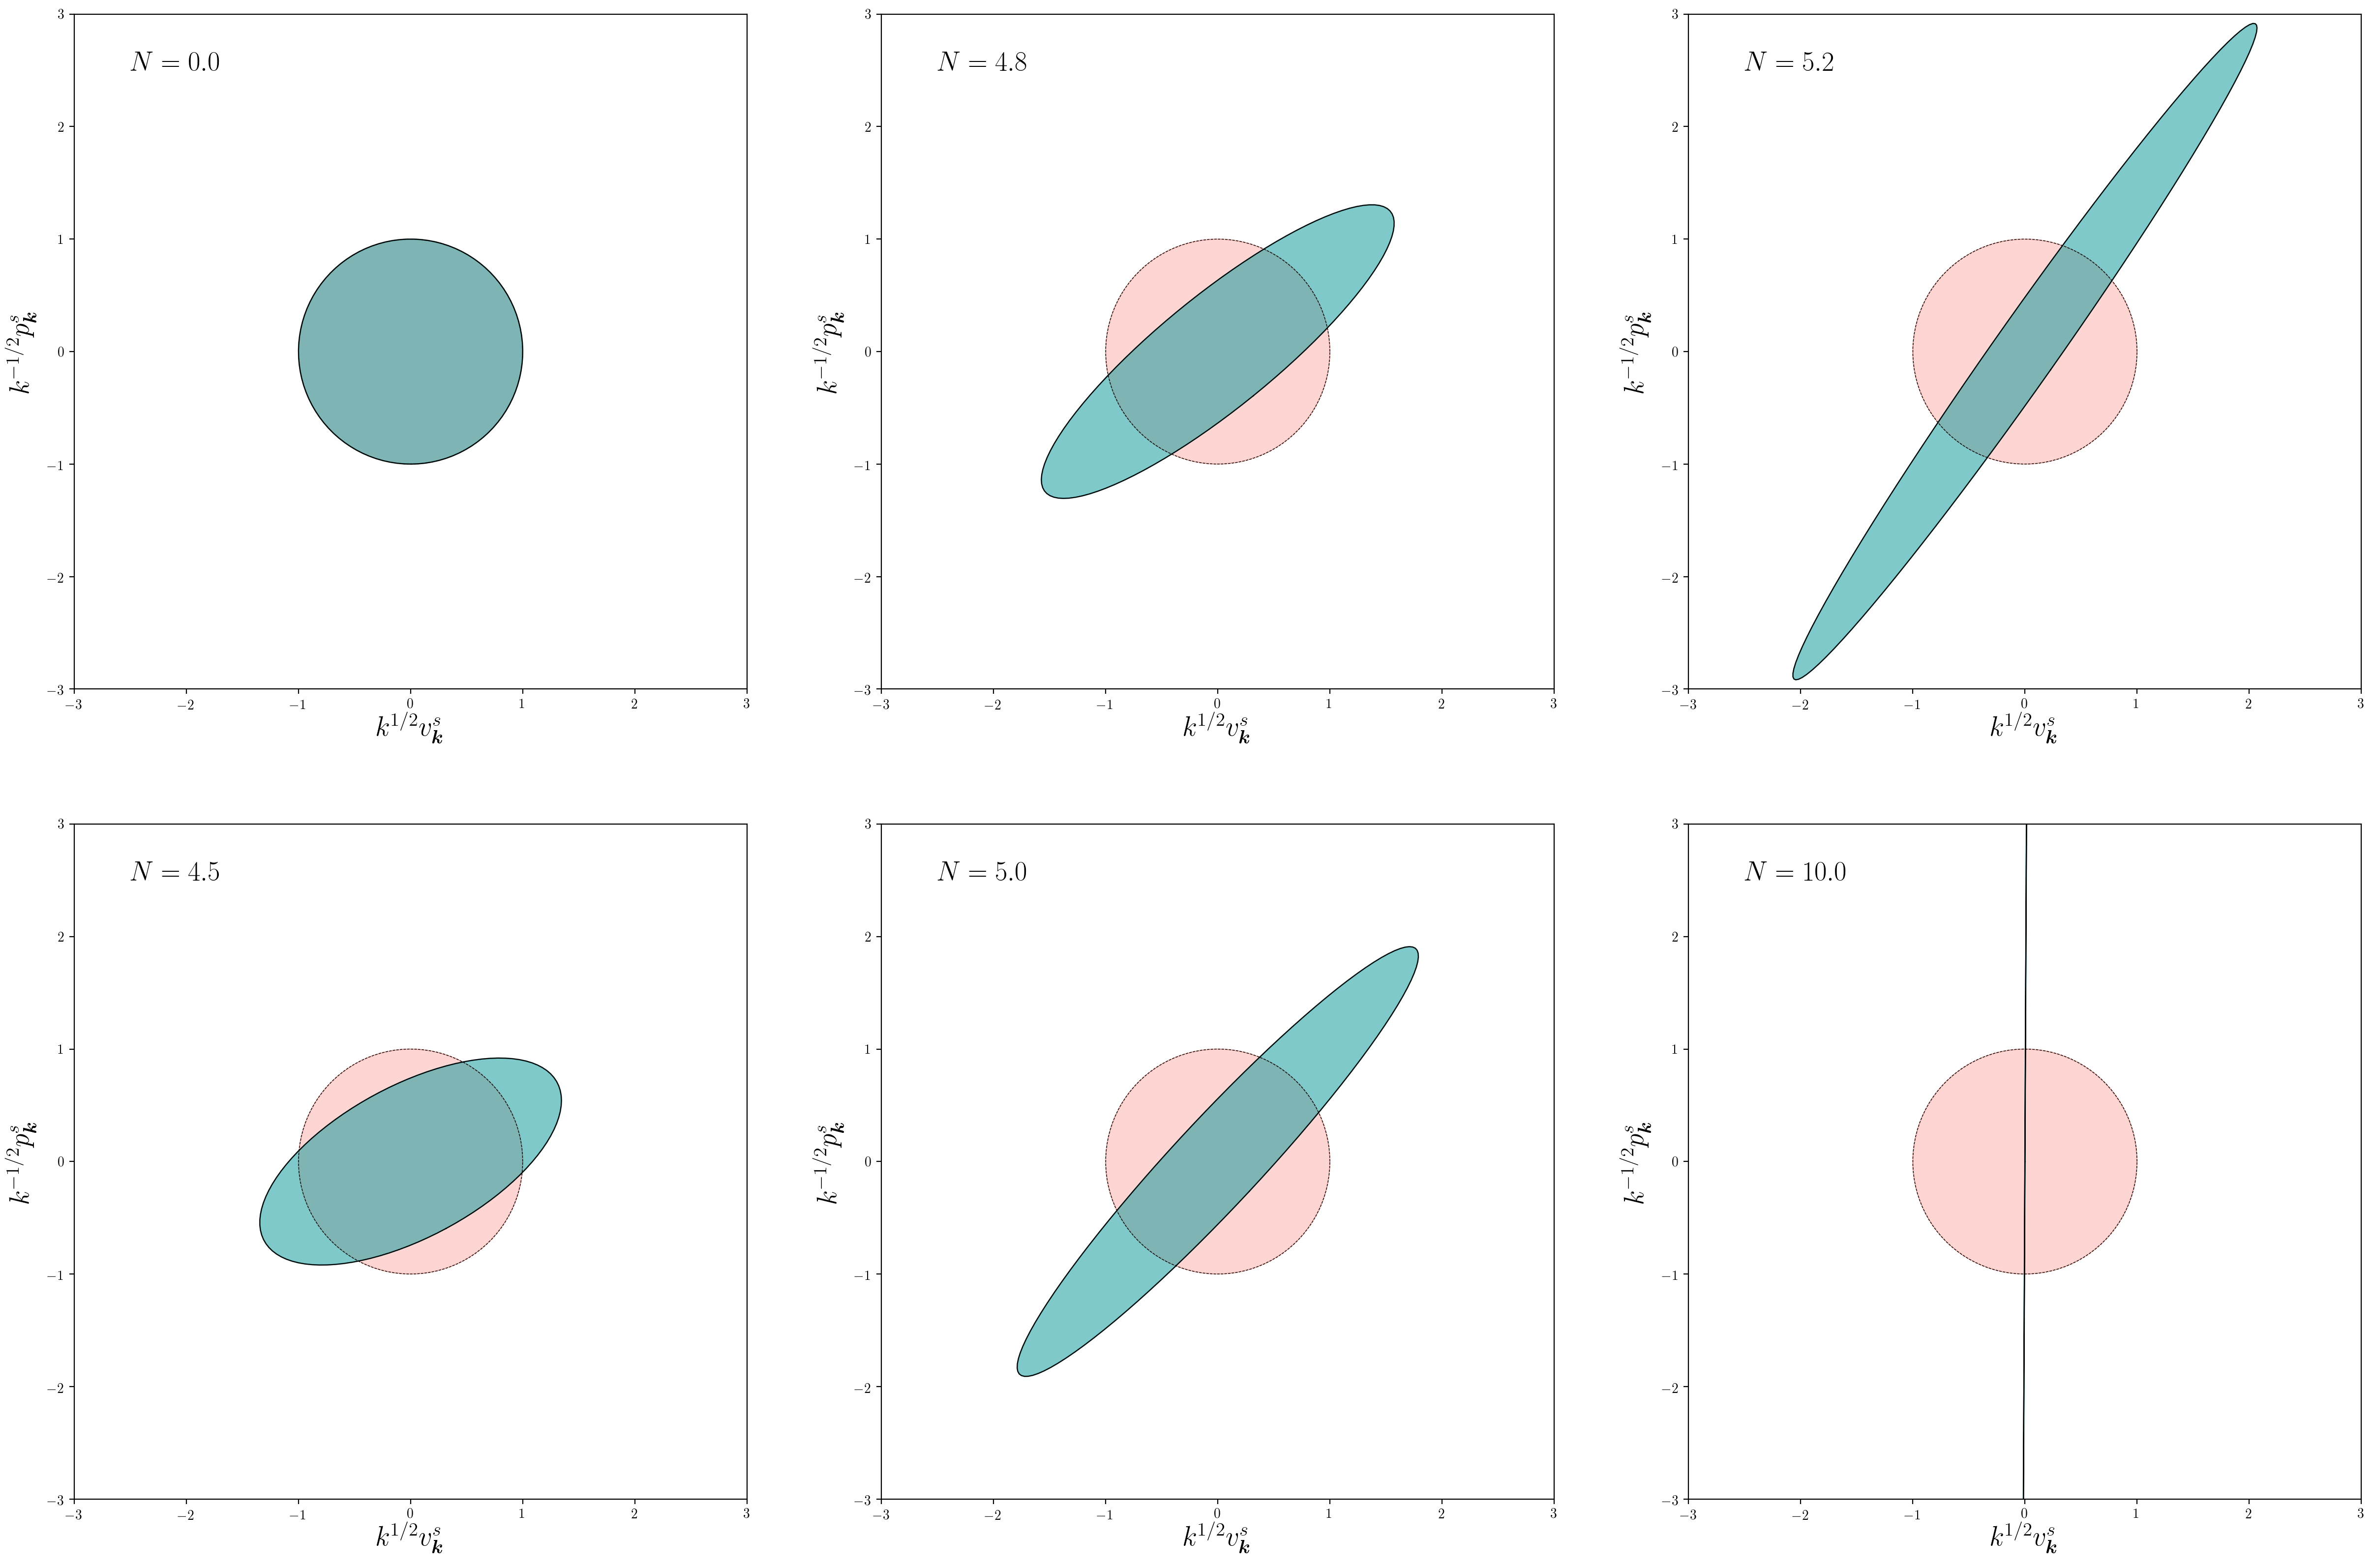

In [53]:
fig, axs = plt.subplots(2, 3,figsize=(30,20)) #The figsize is adjusted to make each subfigure exactly square

Flattened_axs = axs.T.flatten() #Allows to use a simple notation by making the array 1D rather than 2D 

for i in range(6) :
    plt.sca(Flattened_axs[i])
    PlotInnerCircle(0.5)
    PlotEllipse(u,v,rList[i],PhiList[i],LambdaList[i],0.8)
    #PlotAnnotationEllipse(u,v,r,np.pi/2,lamb,0.8,0.4,15)
    #Annotation on the curved arrows
    plt.annotate(s=r'$N='+np.str(np.trunc(NList[i]*10**2)/(10**2))+'$', xy=(-2.5,2.5), color="k", fontsize=20) #xycoords='polar' allows to then give the cooordinates using a polar system
    Flattened_axs[i].axis('equal') #In order to have equal axes
    Flattened_axs[i].set_xlim([-3, 3]) #Set a common scale to all plots
    Flattened_axs[i].set_ylim([-3, 3]) #Set a common scale to all plots
    Flattened_axs[i].set_xlabel(r'$k^{1/2}v^{s}_{\bm{k}}$',fontsize=20)
    Flattened_axs[i].set_ylabel(r'$k^{-1/2}p^{s}_{\bm{k}}$',fontsize=20)
    
plt.savefig('Plots/6RotatedEllipsesdeSitterSameScale.pdf', format='pdf' ,  bbox_inches = 'tight')

plt.show()

## Rotating ellipses with decoherence

In [48]:
u= 0       #x-position of the center
v= 0     #y-position of the center

IndicesList = np.floor(np.linspace(0,np.size(Sigma2dSDecoArray)-1,6)).astype(int)
NList = np.array([0,2.5,3,3.5,4,4.3])
IndicesList = np.floor(NList/deltaN).astype(int)
LambdaList = np.array([LambdakSqueezingArray[i] for i in IndicesList])
rList =  np.array([rkSqueezingArray[i] for i in IndicesList])
PhiList =  np.array([PhikSqueezingArray[i] for i in IndicesList])

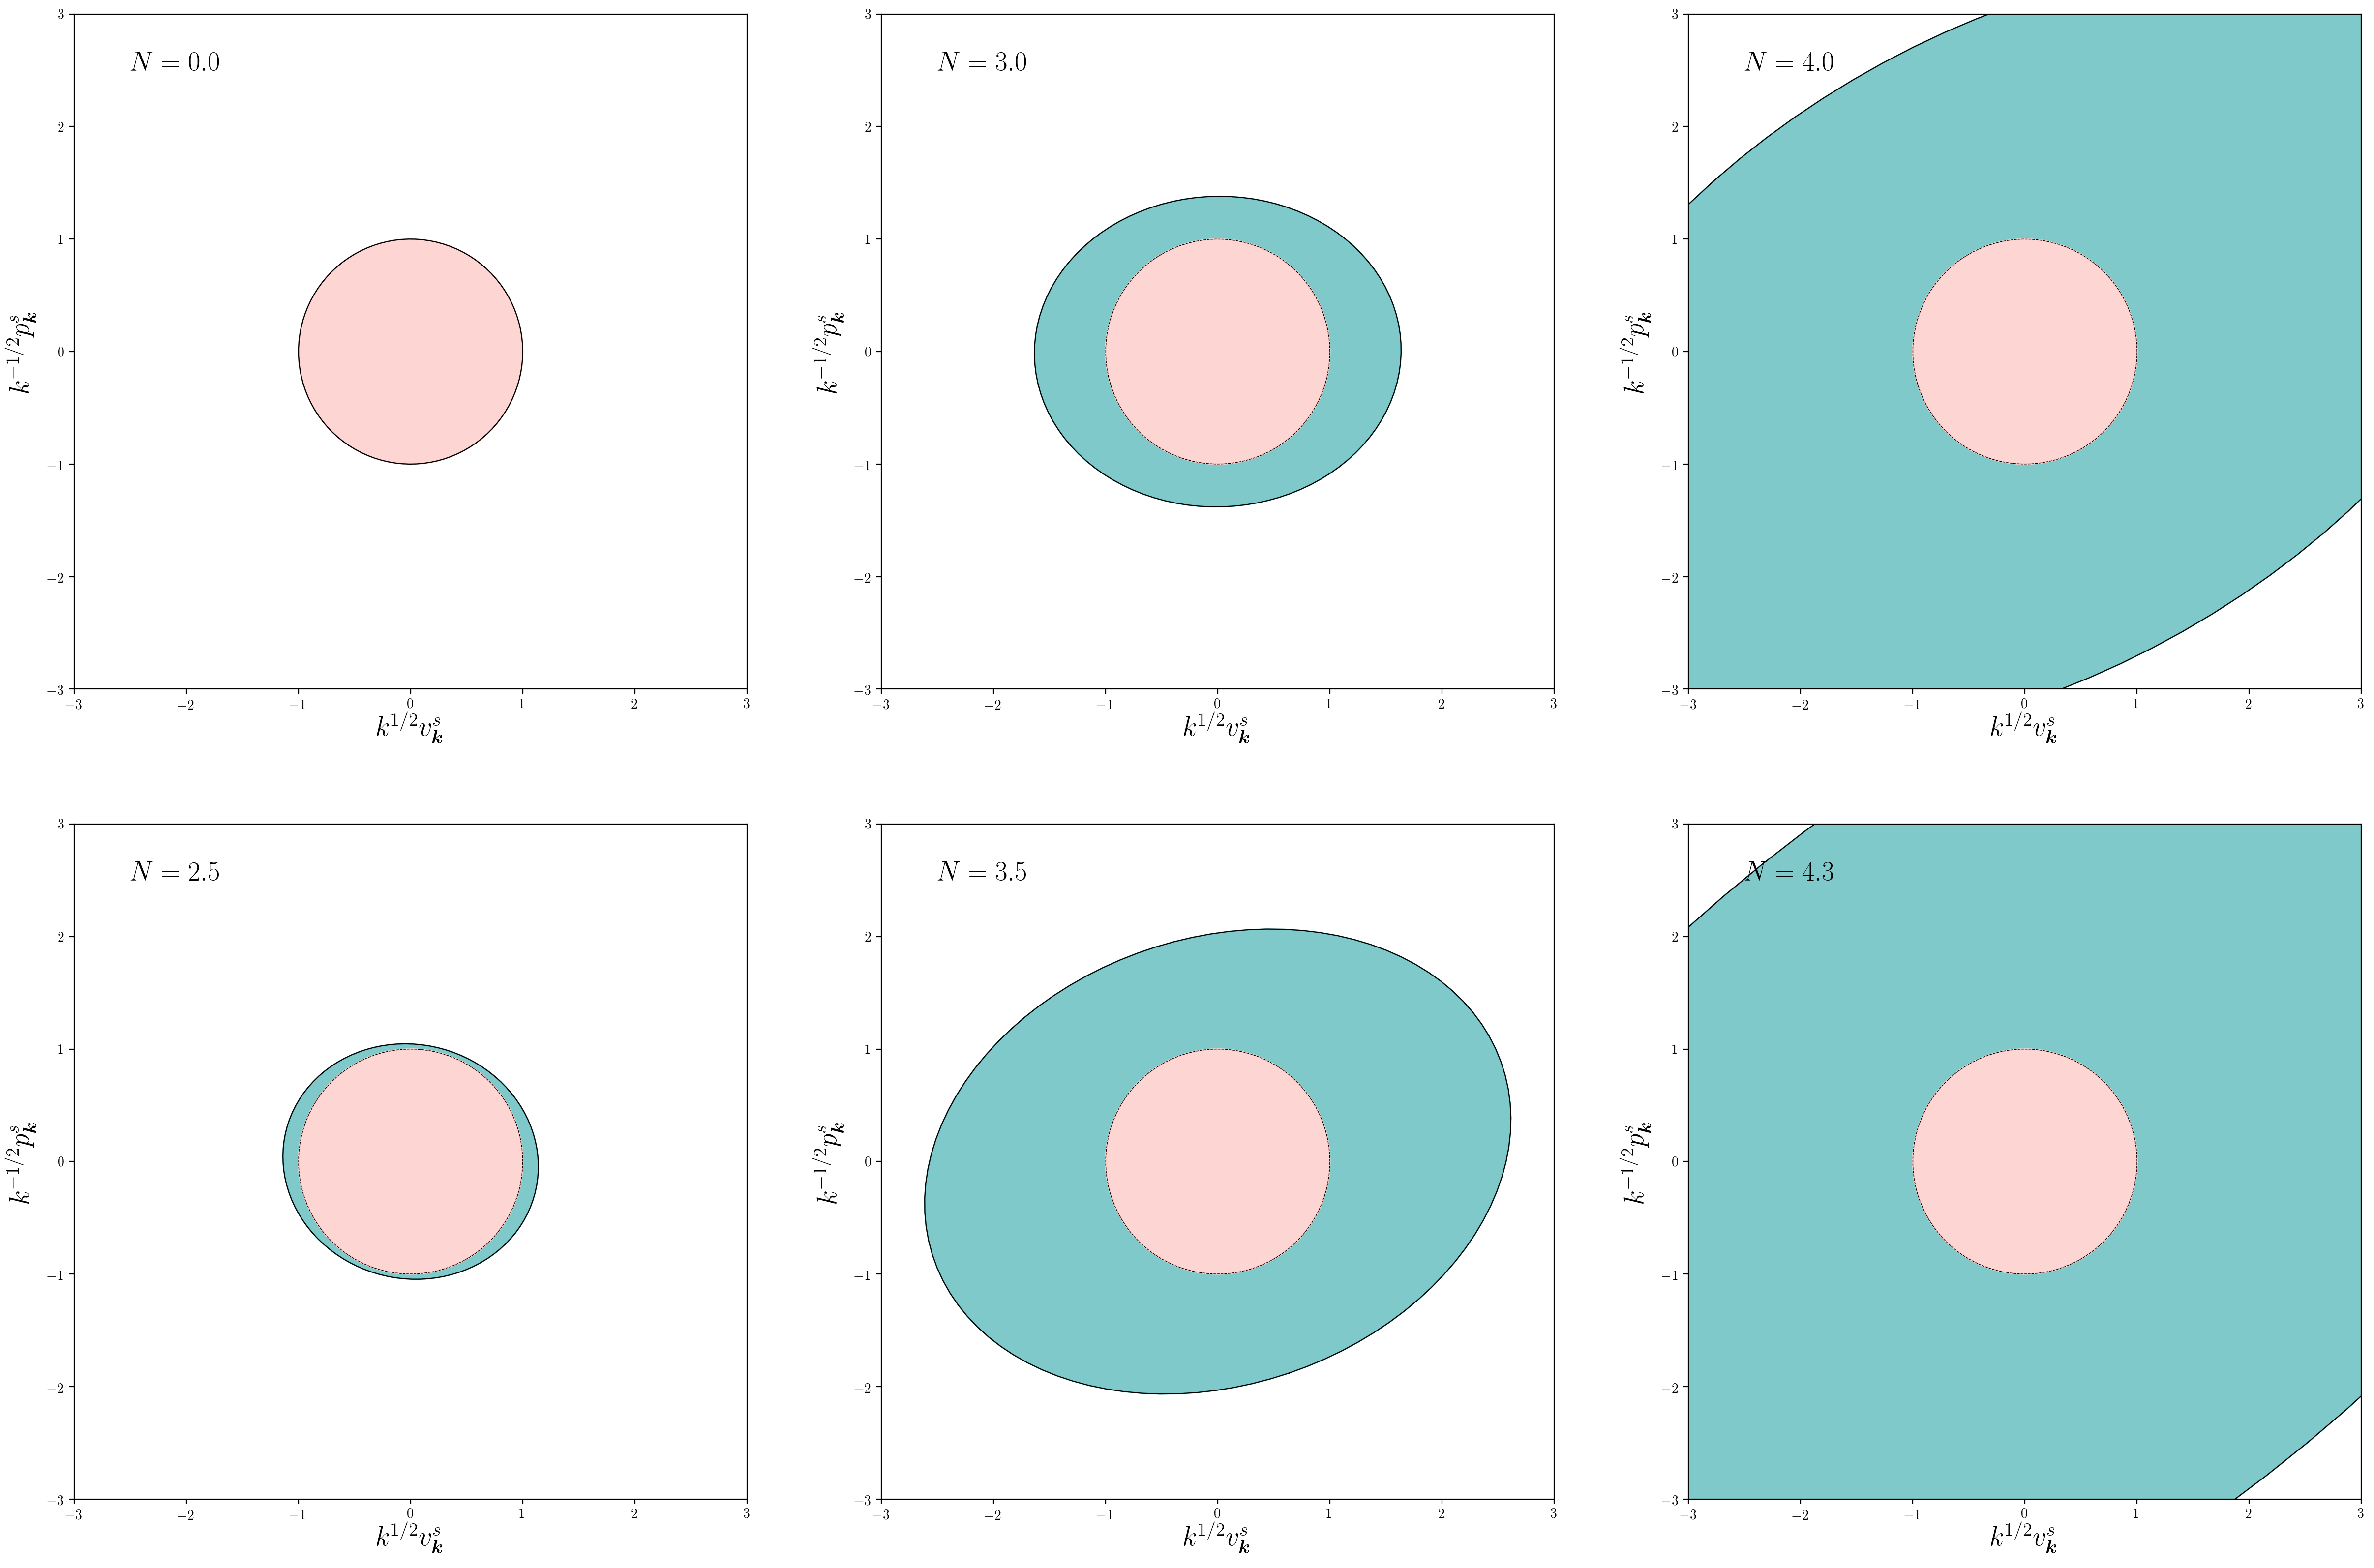

In [49]:
fig, axs = plt.subplots(2, 3,figsize=(30,20)) #The figsize is adjusted to make each subfigure exactly square

Flattened_axs = axs.T.flatten() #Allows to use a simple notation by making the array 1D rather than 2D 

for i in range(6) :
    plt.sca(Flattened_axs[i])
    PlotEllipse(u,v,rList[i],PhiList[i],LambdaList[i],0.8)
    PlotInnerCircleWhite(0.5)
    PlotInnerCircle(0.5)
    plt.annotate(s=r'$N='+np.str(np.trunc(NList[i]*10**2)/(10**2))+'$', xy=(-2.5,2.5), color="k", fontsize=20) #xycoords='polar' allows to then give the cooordinates using a polar system
    Flattened_axs[i].axis('equal') #In order to have equal axes
    Flattened_axs[i].set_xlim([-3, 3]) #Set a common scale to all plots
    Flattened_axs[i].set_ylim([-3, 3]) #Set a common scale to all plots
    Flattened_axs[i].set_xlabel(r'$k^{1/2}v^{s}_{\bm{k}}$',fontsize=20)
    Flattened_axs[i].set_ylabel(r'$k^{-1/2}p^{s}_{\bm{k}}$',fontsize=20)
    

plt.savefig('Plots/6RotatedEllipsesdeSitterSameScaleWithDeco.pdf', format='pdf',  bbox_inches = 'tight')
#plt.savefig('Plots/6RotatedEllipsesdeSitterSameScaleWithDeco.eps' , format='eps')
plt.show()

# Plot of wavelength crossings

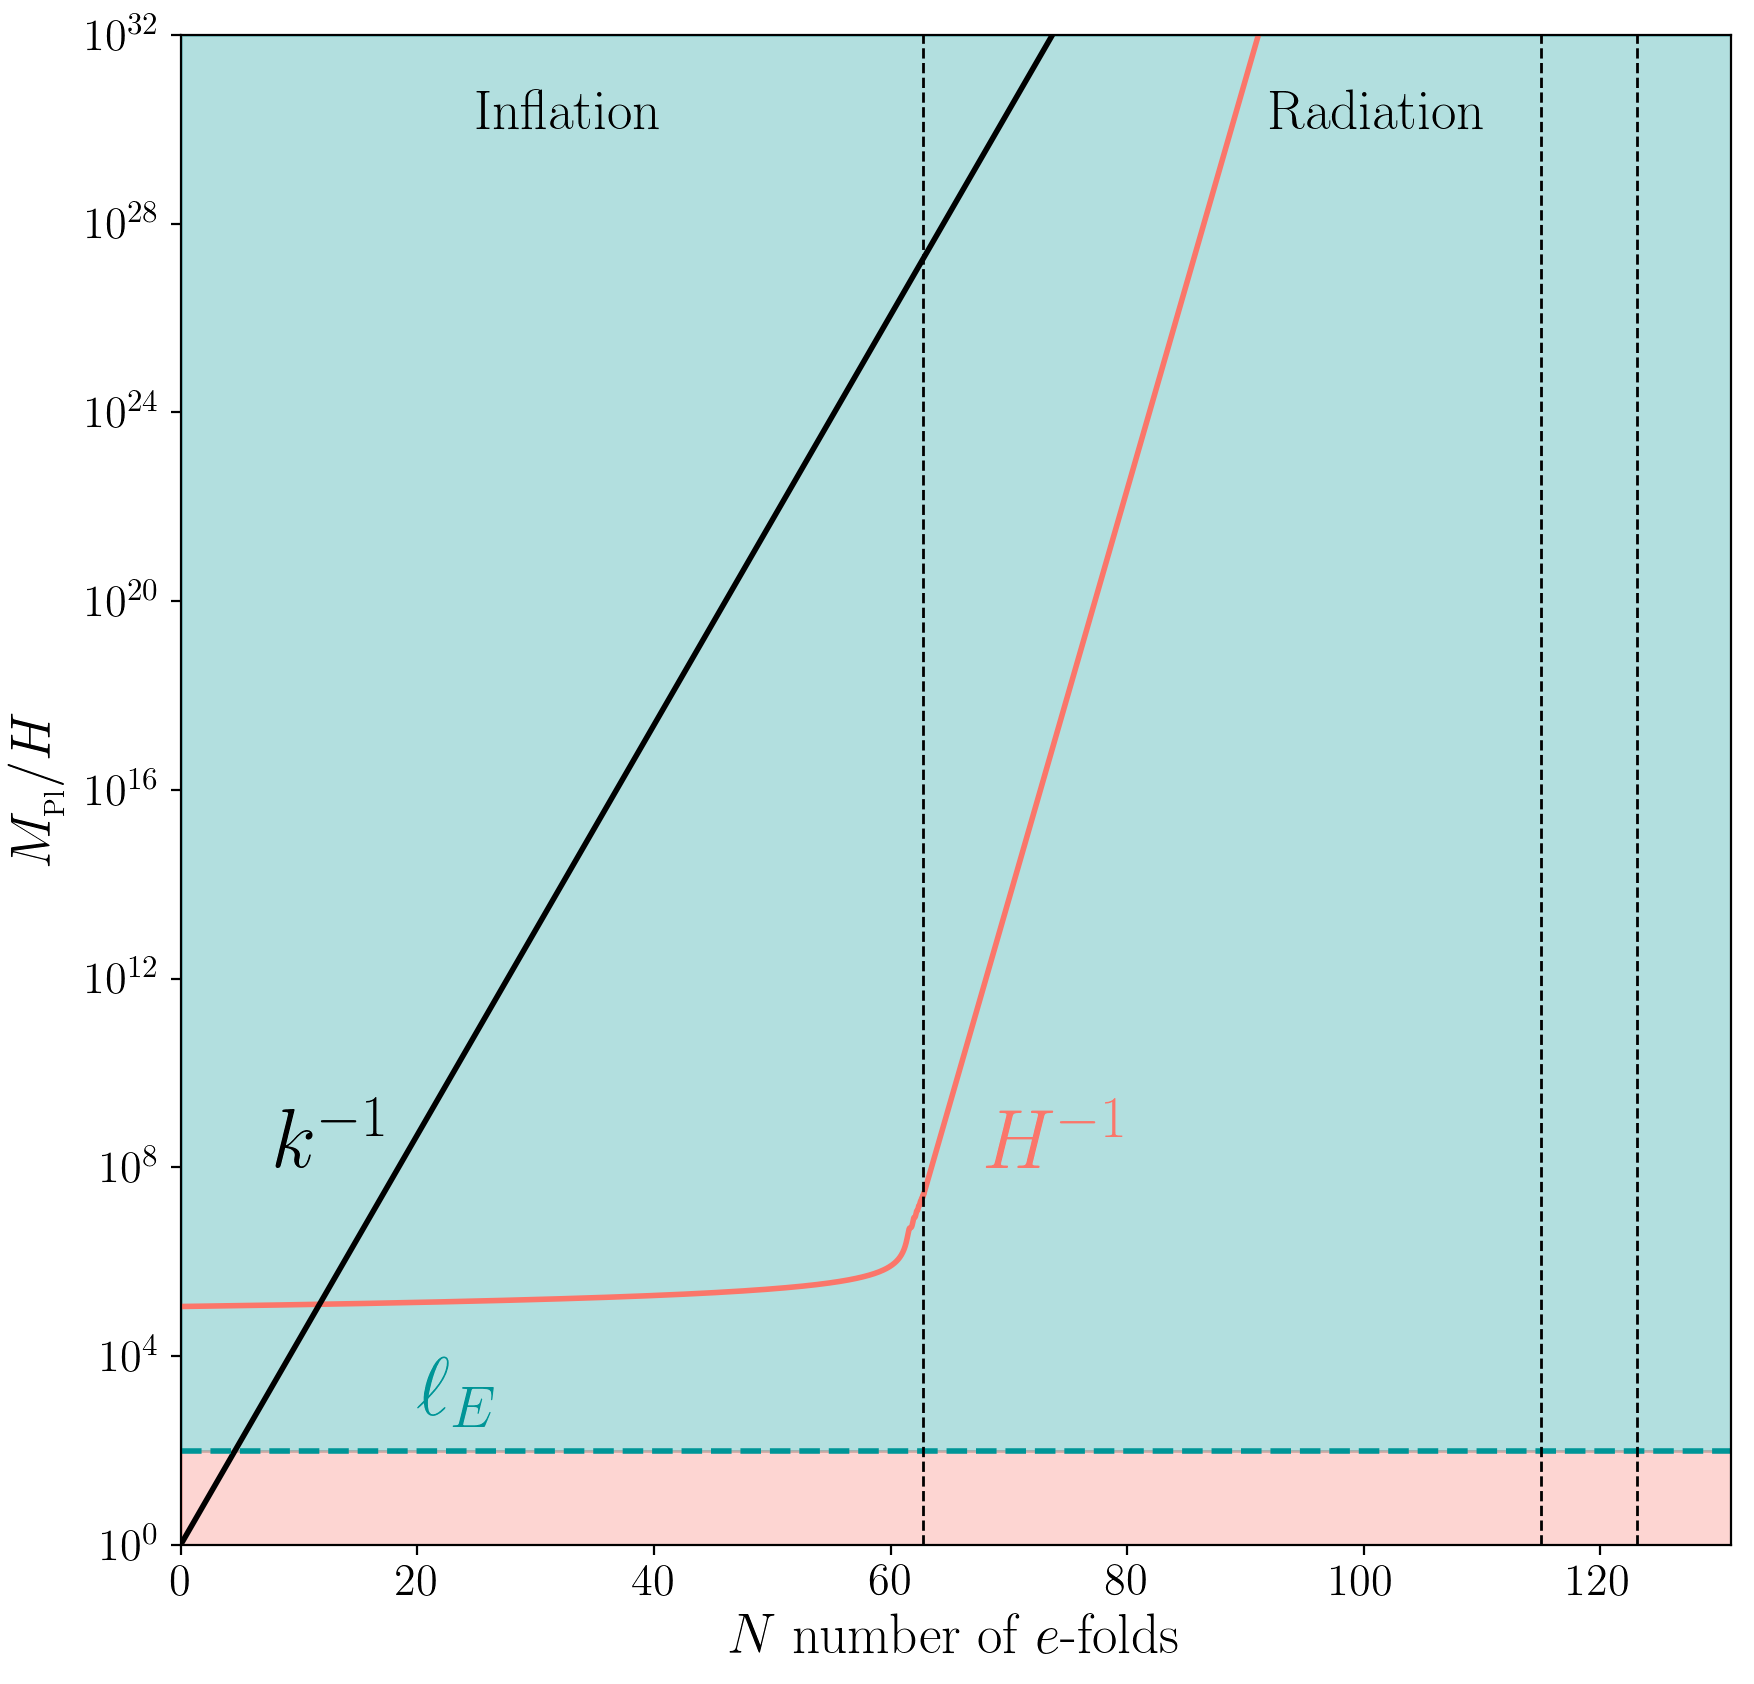

In [35]:
fontSz=20 # font size

fichier=open("Data/result.res",'r')
dt = np.dtype([('Nef', np.dtype(float)),\
               ('H', np.dtype(float)),\
               ('phi', np.dtype(float)),\
               ('kphys', np.dtype(float)),\
               ('klim', np.dtype(float)),\
               ('w', np.dtype(float)),\
               ('bardeen', np.dtype(float)),\
               ('zeta', np.dtype(float)),\
               ('delta', np.dtype(float)),\
               ('v', np.dtype(float)),\
               ('zetav', np.dtype(float)),\
               ('epsilon1',np.dtype(float))])
data=np.loadtxt("Data/result.res",dtype=dt)
fichier.close()
Nef=data['Nef']
H=data['H']
phi=data['phi']
kphys=data['kphys']
klim=data['klim']
w=data['w']
bardeen=data['bardeen']
zeta=data['zeta']
delta=data['delta']
v=data['v']
zetav=data['zetav']
epsilon1=data['epsilon1']

##################################
##           Frame              ##
##################################

xmin=0.
xmax=131.
ymin=10.**(0.)
ymax=10**(32.)

fig = plt.figure(figsize=(10,10)) # Set appropriate figure width/height

ax0 = fig.add_subplot(111)
ax0.axis([0,1,0,1])

plt.tick_params(axis='both', which='major', labelsize=16)

ax0.set_xlim(xmin, xmax)
ax0.set_xlabel(r'$N$ number of $e$-folds',fontsize=fontSz)
ax0.set_ylim(ymin,ymax)
ax0.set_ylabel(r'$M_{_{\rm Pl}}/H$',fontsize=fontSz)

#ax0.set_xscale('log')
ax0.set_yscale('log')

Nef_filtered=Nef[Nef<62.7820]
H_filtered = H[Nef<62.7820]




N0cross=123.132
Nicross=62.7820
H0cross=2.1332*np.sqrt(8.*3.14)*10.**(-61.)/1.2211
Orad=2.48*10.**(-5.)
Om=0.1198+0.02255
Ol=0.306


#Plot Hubble radius

def Hubbleinv(x):
    return (340*H0cross*np.sqrt(Orad*np.exp(4.*(N0cross-x))+Om*np.exp(3.*(N0cross-x))+Ol))**(-1.)

Npoints = 1000
Ntabcross = np.arange(62.7820, xmax, (xmax-xmin)/Npoints)

plt.plot(Ntabcross,Hubbleinv(Ntabcross),color=LivingCoral,linestyle='-',linewidth='2')
plt.plot(Nef_filtered,H_filtered**(-1.),color=LivingCoral,linestyle='-',linewidth='2')

ax0.text(68.,10**(8.), r'$H^{-1}$', fontsize=30,color=LivingCoral)




#Plot wavelength associated to k


def scale(x):
    return np.exp(x)

Npoints = 1000
Ntabcross2 = np.arange(0., xmax, (xmax-xmin)/Npoints)


plt.plot(Ntabcross2,scale(Ntabcross2),'Black',linestyle='-',linewidth='2')

ax0.text(8.,10**(8.), r'$k^{-1}$', fontsize=30,color='Black')

#Plot of lE

ax0.text(20.,10**(2.5), r'$\ell_E$', fontsize=30,color=ViridianGreen)
plt.plot([xmin,xmax],[10.**(2.),10**(2.)],color=ViridianGreen,linestyle='--',linewidth=2.)
#ax0.fill_between([xmin,xmax],[10.**(15.),10**(15.)],[ymax,ymax],color='lavender',alpha=0.8)

ax0.fill_between([xmin,xmax],[10.**(2.),10**(2.)],[ymax,ymax],color=ViridianGreen,alpha=0.3)

ax0.fill_between([xmin,xmax],[ymin,ymin],[10.**(2.),10**(2.)],color=LivingCoral,alpha=0.3)




##################################
##           Legend             ##
##             and              ##
##         Annotations          ##
##################################

plt.plot([62.7820,62.7820],[ymin,ymax],'k',linestyle='--',linewidth=1.)
plt.plot([115,115],[ymin,ymax],'k',linestyle='--',linewidth=1.)
plt.plot([123.132,123.132],[ymin,ymax],'k',linestyle='--',linewidth=1.)

ymin_of_x=[0.]*len(Ntabcross)
for i in np.arange(0,len(Ntabcross),1):
    ymin_of_x[i]=ymin

ymax_of_x=[0.]*len(Ntabcross)
for i in np.arange(0,len(Ntabcross),1):
    ymax_of_x[i]=ymax

ymin_of_Nef_filtered=[0.]*len(Nef_filtered)
for i in np.arange(0,len(Nef_filtered),1):
    ymin_of_Nef_filtered[i]=ymin

ymax_of_Nef_filtered=[0.]*len(Nef_filtered)
for i in np.arange(0,len(Nef_filtered),1):
    ymax_of_Nef_filtered[i]=ymax



#max_xmin_Hubbleinv_array=Nef_filtered
#for i in np.arange(0,len(Nef_filtered),1):
#    max_xmin_Hubbleinv_array[i]=max_xmin_Hubbleinv(Nef_filtered[i])

#ax0.fill_between(x,ymin_of_x,Hubbleinv(x),color=StormGray,alpha=0.5)

#ax0.fill_between(Nef_filtered,ymin_of_Nef_filtered,H_filtered**(-1.),color=StormGray,alpha=0.5)

#ax0.fill_between(x,Hubbleinv(x),ymax_of_x,color=LivingCoral,alpha=0.5)

#ax0.fill_between(Nef_filtered,H_filtered**(-1.),ymax_of_Nef_filtered,color=LivingCoral,alpha=0.5)




ax0.text(25.,10**(30.), 'Inflation',fontsize=fontSz)
ax0.text(92.,10**(30.), 'Radiation',fontsize=fontSz)



##################################
##         Save figure          ##
##################################


# Save the figure into .eps file
#savefig('background_inhomo_scalarfield.eps', format='eps',bbox_inches='tight',pad_inches=0.1)
formatname='pdf'
plt.savefig('Plots/WavelengthCrossingsGreen.'+formatname, format=formatname,bbox_inches='tight',pad_inches=0.1)
#show()
#exit(0)

plt.show()

# OLD : Evolution in presence of decoherence (Useless since we are not doing numerical integration anymore)

In [160]:
N_1 = N_max
N_max1 = 60.96
deltaN= 0.01
Ntab1 = np.arange(N_1, N_max1, deltaN)

Check that the decoherence does happen when supposed to

In [39]:
icross_ref = np.floor((Ncross_ref-N_max)/deltaN).astype(int)

In [40]:
IntegDeco11(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref)

NameError: name 'Ntab1' is not defined

In [178]:
IntegDeco12(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref)

array([ 0.        , -0.0215886 , -0.11661776, -0.28125401, -0.50671251,
       -0.78240792, -1.09647012, -1.43626397, -1.78889276, -2.1416678 ])

In [177]:
IntegDeco22(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref)

array([ 0.        , -0.58277146, -1.33425173, -2.02144975, -2.62090569,
       -3.11356516, -3.48518569, -3.72652625, -3.8333349 , -3.80615583])

We feed the new initial condition for the Gamma. Notice that using the EOM on the new variables the Gammas stayed constant so that we feed them with the Gammas obtained from the EOM on the original variables. 


In [179]:
UnivPlusGammas_1 = np.concatenate((solPreGamma.y[0:7,-1],  np.array([solPreGamma.y[2,-1],solPreGamma.y[2,-1]*solPreGamma.y[4,-1]-solPreGamma.y[3,-1]**2,solPreGamma.y[4,-1]]) ))
# UnivPlusGammas_1 = [ 2.88825403e+00, -2.27005780e-07,  2,        1,  1]    
phi_1 = UnivPlusGammas_1[0]
phidot_1 = UnivPlusGammas_1[1]

Computing the evolution with decoherence from $N_1$ to $N_{\rm max , 1}$

In [180]:
# kphys_0 = 30513940073
# 
# UnivPlusGammas_0 = [phi_0,phidot_0,1,0,1,1,1j*kphys_0,1,1,1]
# 
# k_0 = kphys_0*a_0*H(N_0,UnivPlusGammas_0[0],UnivPlusGammas_0[1])
# 
# solGamma = solve_ivp(UnivPlusGammaEOM, (N_1,N_max1) , UnivPlusGammas_1 , t_eval= Ntab1  )

solGamma = solve_ivp(UnivPlusGammaDecoherenceEOM, (N_1,N_max1) , UnivPlusGammas_1 , t_eval= Ntab1  )

Computing the covariance matrix elements $\gamma_{ij}$ in the presence of decoherence

In [181]:
Gam11dSDeco = Gamma11dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam12dSDeco = Gamma12dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)
Gam22dSDeco = Gamma22dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE_ref,p_ref,xstar_ref)

Check that w. and w.o. decoherence quantities only differ when they should

In [204]:
np.log(Gamma11dS(Ntab1,solGamma.y[0],solGamma.y[1]))[icross_ref:icross_ref+10]-np.log(np.abs(Gam11dSDeco))[icross_ref:icross_ref+10]

array([ 0.        +0.j, -0.05137216+0.j, -0.51160004+0.j, -1.2639271 +0.j,
       -1.98340954+0.j, -2.59093049+0.j, -3.09700629+0.j, -3.52275295+0.j,
       -3.88559183+0.j, -4.19841083+0.j])

Plot $\gamma_{11}$ NB : Even if the logarithms of the de Sitter with and without decoherence are very close, they do differ by $10^{42}$, but they are of order 10^46 so that the relative difference as measured by the log is small 

/home/amaury/.local/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


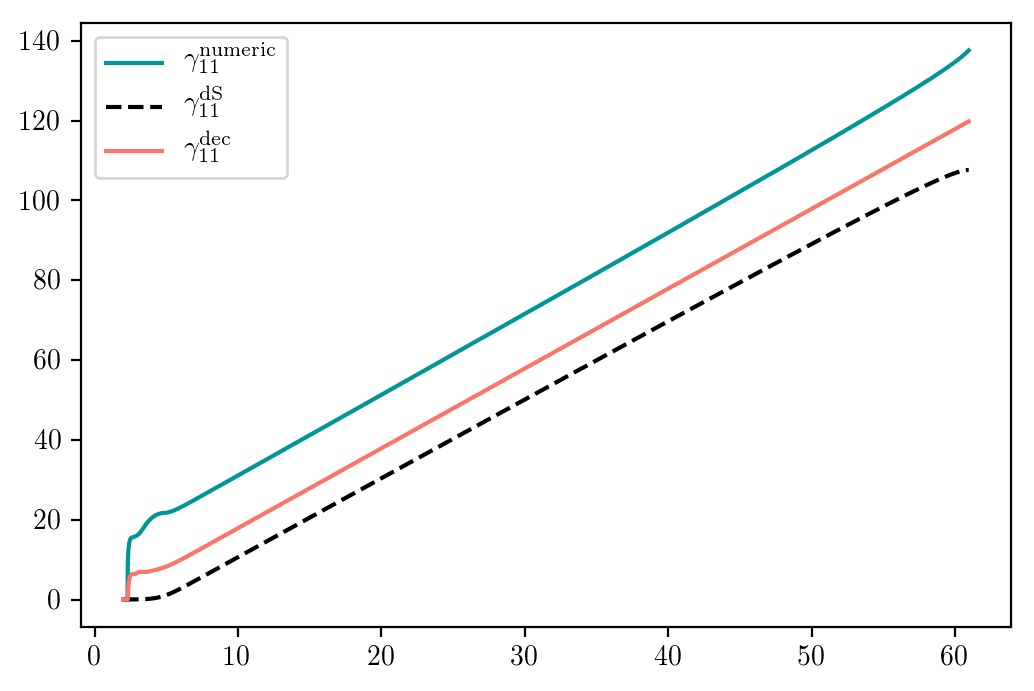

In [188]:
plt.plot(Ntab1,np.log(np.abs(solGamma.y[7])),color=ViridianGreen,label=r'$\gamma_{11}^{\rm numeric}$')
plt.plot(Ntab1,np.log(Gamma11dS(Ntab1,solGamma.y[0],solGamma.y[1])),'k--',label=r'$\gamma_{11}^{\rm dS}$')
plt.plot(Ntab1,np.log(np.abs(Gam11dSDeco)),color=LivingCoral,label=r'$\gamma_{11}^{\rm dec}$')
plt.legend()
plt.savefig('Gamma11SecondEvoWithDeco.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

Check that w. and w.o. decoherence quantities only differ when they should

In [190]:
np.log(Gamma12dS(Ntab1,solGamma.y[0],solGamma.y[1]))[icross_ref:icross_ref+10]-np.log(np.abs(Gam12dSDeco))[icross_ref:icross_ref+10]

array([  0.        +0.j,  -7.0207857 +0.j,  -8.67705558+0.j,
        -9.52757141+0.j, -10.08648268+0.j, -10.49115818+0.j,
       -10.79888286+0.j, -11.03908475+0.j, -11.2288906 +0.j,
       -11.37913386+0.j])

Plot Gamma12

/home/amaury/.local/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


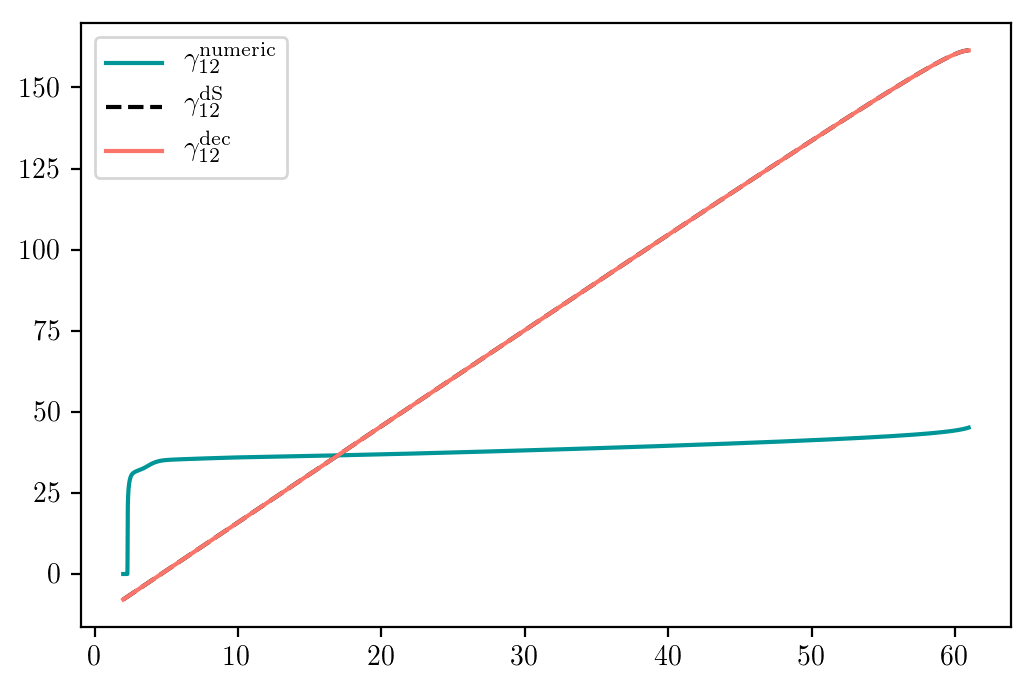

In [189]:
plt.plot(Ntab1,np.log(np.abs(solGamma.y[8])),color=ViridianGreen,label=r'$\gamma_{12}^{\rm numeric}$')
plt.plot(Ntab1,np.log(Gamma12dS(Ntab1,solGamma.y[0],solGamma.y[1])),'k--',label=r'$\gamma_{12}^{\rm dS}$')
plt.plot(Ntab1,np.log(np.abs(Gamma12dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE,p_ref,xstar_ref))),color=LivingCoral,label=r'$\gamma_{12}^{\rm dec}$')
plt.legend()
plt.savefig('Gamma12SecondEvoWithDeco.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

In [192]:
np.log(Gamma22dS(Ntab1,solGamma.y[0],solGamma.y[1]))[icross_ref:icross_ref+10]-np.log(np.abs(Gam22dSDeco))[icross_ref:icross_ref+10]

array([-1.73472348e-18+0.j, -3.41693081e+00+0.j, -4.23474717e+00+0.j,
       -4.65999605e+00+0.j, -4.93923482e+00+0.j, -5.13962073e+00+0.j,
       -5.28949562e+00+0.j, -5.40362720e+00+0.j, -5.49079469e+00+0.j,
       -5.55673919e+00+0.j])

In [208]:
np.log(np.abs(-(kgam_ref/k_0)**2*IntegDeco22(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref,p_ref,xstar_ref)/2/Gamma22dS(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10]))) 

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


array([      -inf, 3.38177932, 4.21030372, 4.62594546, 4.88585178,
       5.05830559, 5.17126788, 5.23843659, 5.266913  , 5.26001963])

In [ ]:
-(1-2/(kphys_0*np.exp(-(N-N_0)))**2)*(kgam/k_0)**2*IntegDeco11(N,phi,phidot,lE, p, xstar)/2

Plot Gamma22

/home/amaury/.local/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


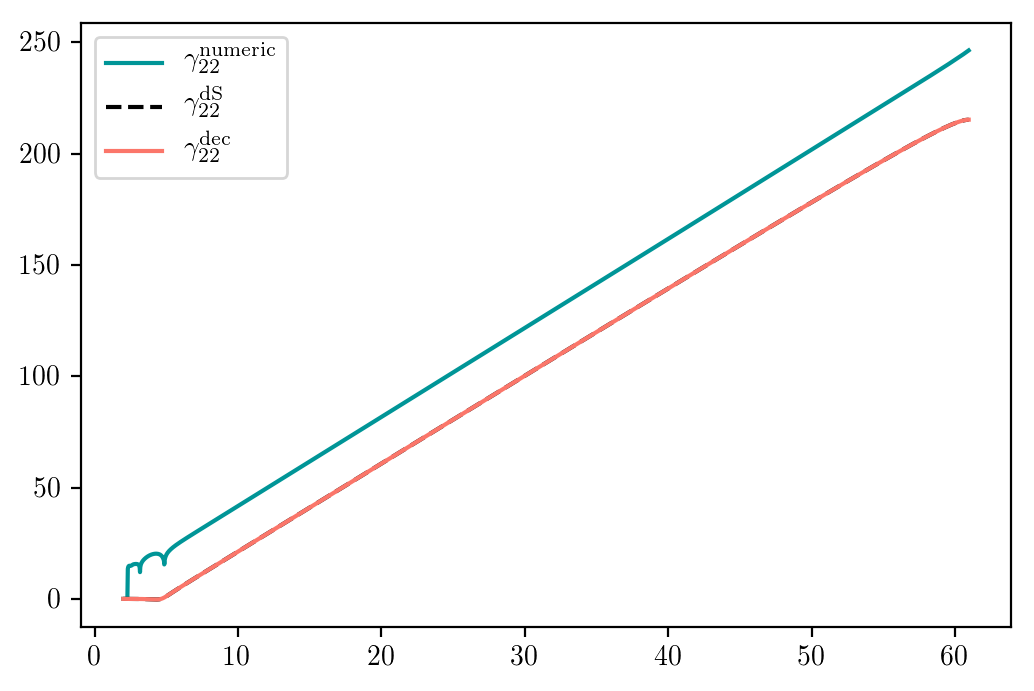

In [191]:
plt.plot(Ntab1,np.log(np.abs(solGamma.y[9])),color=ViridianGreen,label=r'$\gamma_{22}^{\rm numeric}$')
plt.plot(Ntab1,np.log(Gamma22dS(Ntab1,solGamma.y[0],solGamma.y[1])),'k--',label=r'$\gamma_{22}^{\rm dS}$')
plt.plot(Ntab1,np.log(np.abs(Gamma22dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE,p_ref,xstar_ref))),color=LivingCoral,label=r'$\gamma_{22}^{\rm dec}$')
plt.legend()
plt.savefig('Gamma22SecondEvoWithDeco.pdf', format='pdf' ,  bbox_inches = 'tight')
plt.show()

$\sigma^2(0)$ with decoherence (Too hard to compute by taking product)

/home/amaury/.local/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


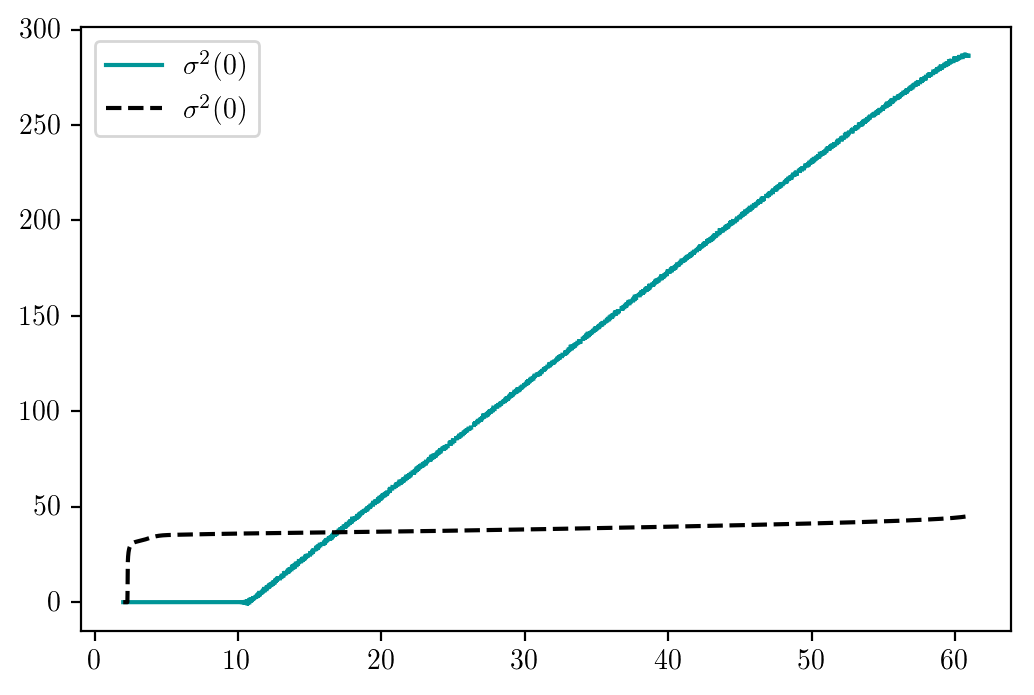

In [187]:
plt.plot(Ntab1,np.log(np.abs(Gamma11dS(Ntab1,solGamma.y[0],solGamma.y[1])*Gamma22dS(Ntab1,solGamma.y[0],solGamma.y[1])-Gamma12dS(Ntab1,solGamma.y[0],solGamma.y[1])**2)) ,color=ViridianGreen,label=r'$\sigma^2(0)$')
plt.plot(Ntab1,np.log(np.abs(solGamma.y[8])) ,'k--',label=r'$\sigma^2(0)$')
#
#plt.plot(Ntab1,np.log(np.abs(Gamma11dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE,p_ref,xstar_ref)*Gamma22dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE,p_ref,xstar_ref)-Gamma12dSDeco(Ntab1,solGamma.y[0],solGamma.y[1],kgam_ref,lE,p_ref,xstar_ref)**2)),color=LivingCoral,label=r'$\sigma^2_{\rm deco}(0)$')
plt.legend()
plt.show()

Plot integrals to check that they are not $0$ anymore

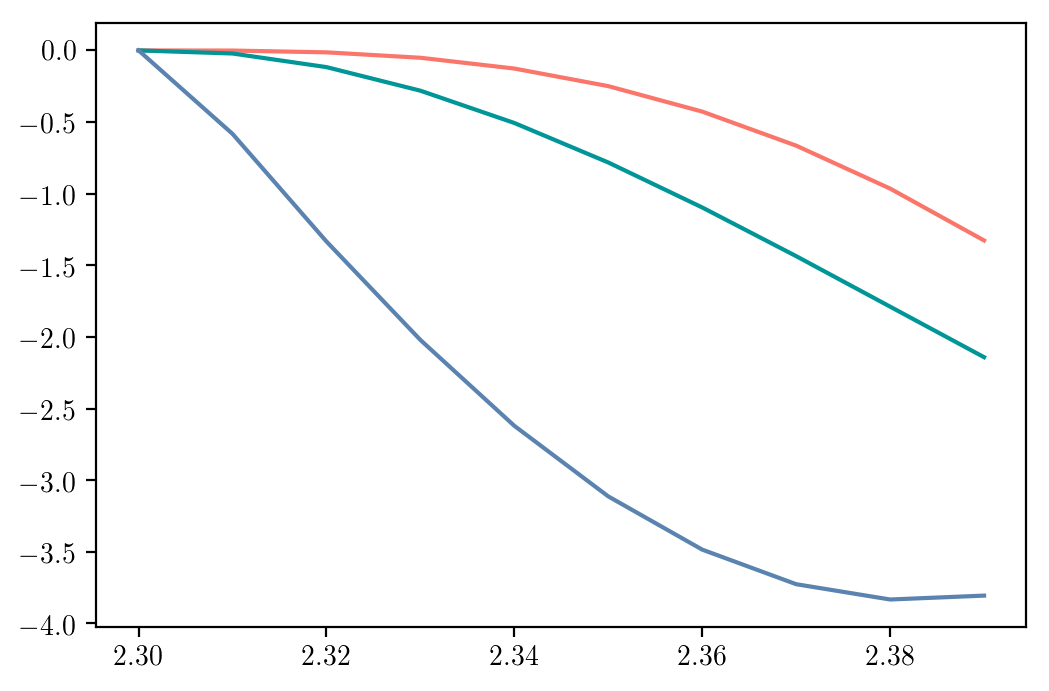

In [196]:
plt.plot(Ntab1[icross_ref:icross_ref+10],IntegDeco11(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref),color=LivingCoral)
plt.plot(Ntab1[icross_ref:icross_ref+10],IntegDeco12(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref),color=ViridianGreen)
plt.plot(Ntab1[icross_ref:icross_ref+10],IntegDeco22(Ntab1[icross_ref:icross_ref+10],solGamma.y[0][icross_ref:icross_ref+10],solGamma.y[1][icross_ref:icross_ref+10],lE_ref, p_ref, xstar_ref),color=PacificCoast)
plt.show()